In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
from ela_table_helper import *

columns = ["sampling_strategy", "sample_size_per_dim", "n_instances_train", "n_runs_train", "n_feval_train", "accuracy_median", "accuracy_allruns", "cv_instance_median_mean", "cv_function_median_mean"]

## Dimension 2

In [2]:
table_pkl_dim2 = Path("~/t7ssd/classification_results_consistent_features/dim2/subsample_results_table.pkl")
df = pd.read_pickle(table_pkl_dim2)
df.columns

Index(['dimension', 'sampling_strategy', 'sample_size_per_dim',
       'n_instances_train', 'n_runs_train', 'n_feval_train', 'fold',
       'n_features', 'n_omitted_features', 'omitted_features',
       'cv_instance_median_mean', 'cv_instance_median_median',
       'cv_function_median_mean', 'cv_function_median_median',
       'cv_training_folds_median_mean', 'cv_training_folds_median_median',
       'accuracy_median', 'accuracy_allruns', 'consistency'],
      dtype='str')

| Column | Description |
|--------|-------------|
| `dimension` | Problem dimensionality (e.g. 2 or 5). |
| `sampling_strategy` | Sampling strategy used (e.g. `ilhs`, `cma_random`), parsed from the config key. |
| `sample_size_per_dim` | Base sample size per dimension. Actual sample size = `sample_size_per_dim × dimension`. |
| `feval_training` | Total function evaluations for training: `(sample_size_per_dim × dim) × 24 functions × 80 instances × n_runs_train`. |
| `runs_training_per_instance` | Number of independent runs per instance used for training (e.g. 1–30). |
| `cv_instance_median_mean` | Per-instance CV: for each feature, take the median CV across all 24×100 instances, then the **mean** across features. |
| `cv_instance_median_median` | Per-instance CV: for each feature, take the median CV across all 24×100 instances, then the **median** across features. |
| `cv_function_median_mean` | Per-function CV: for each feature, take the median CV across 24 functions, then the **mean** across features. |
| `cv_function_median_median` | Per-function CV: for each feature, take the median CV across 24 functions, then the **median** across features. |
| `cv_training_folds_function_median_mean` | Training-set CV: for each feature, take the median CV across 24 functions × 5 folds, then the **mean** across features. |
| `cv_training_folds_function_median_median` | Training-set CV: for each feature, take the median CV across 24 functions × 5 folds, then the **median** across features. |
| `accuracy_median_mean` | Mean 5-fold classification accuracy using median-aggregated features per test instance. |
| `accuracy_median_sd` | Std dev of 5-fold classification accuracy (median-aggregated features)|
| `accuracy_allruns_mean` | Mean 5-fold classification accuracy using all individual runs per test instance. |
| `accuracy_allruns_sd` | Std dev of 5-fold classification accuracy (all runs)|

In [3]:

group_cols = [
    "dimension",
    "sampling_strategy",
    "sample_size_per_dim",
    "n_instances_train",
    "n_runs_train",
    "n_feval_train",
]

# aggregate over the 5 folds
fold_agg_df = (
    df
    .groupby(group_cols, as_index=False)
    .agg(
        acc_mean=("accuracy_median", "mean"),
        acc_sd=("accuracy_median", "std"),
        acc_allruns_mean=("accuracy_allruns", "mean"),
        consistency_mean=("consistency", "mean"),
        cv_instance_median_mean=("cv_instance_median_mean", "first"),
        cv_instance_median_median=("cv_instance_median_median", "first"),
        cv_function_median_mean=("cv_function_median_mean", "first"),
        cv_function_median_median=("cv_function_median_median", "first"),
        # feature meta‑info (optional)
        # n_features=("n_features", "first"),
        # n_omitted_features=("n_omitted_features", "first"),
        # omitted_features=("omitted_features", "first"),
    )
)

In [4]:
## Per instance cv of features, median across dataset, and mean across features
df_unique = df.drop_duplicates(subset=["sampling_strategy", "sample_size_per_dim"])
pivot = df_unique.pivot(index="sampling_strategy", columns="sample_size_per_dim",
                        values="cv_instance_median_mean")
pivot

sample_size_per_dim,25,50,75,100
sampling_strategy,,,,
cma_random,0.490284,0.467463,0.490092,0.526402
ilhs,0.211366,0.174404,0.116454,0.103149
lhs,0.291499,0.237537,0.147355,0.132414
sobol,0.240613,0.161319,0.135615,0.130909
uniform,0.319444,0.261273,0.177362,0.198552


In [5]:
pd.qcut(df["n_feval_train"], q=4).value_counts()

n_feval_train
(1199.999, 14400.0]    900
(14400.0, 36000.0]     850
(77700.0, 480000.0]    800
(36000.0, 77700.0]     650
Name: count, dtype: int64

In [47]:
df["n_feval_train"].value_counts()


n_feval_train
36000     200
72000     200
24000     175
7200      150
48000     150
12000     125
18000     125
14400     125
4800      100
54000     100
144000    100
2400       75
3600       75
10800      75
120000     75
9600       75
21600      75
108000     75
96000      75
6000       50
16800      50
25200      50
60000      50
90000      50
33600      50
50400      50
180000     50
240000     50
216000     50
360000     50
28800      50
1200       25
30000      25
8400       25
42000      25
84000      25
32400      25
75600      25
126000     25
162000     25
270000     25
19200      25
43200      25
67200      25
100800     25
168000     25
192000     25
288000     25
480000     25
Name: count, dtype: int64

In [7]:
df["omitted_features"].unique()

<StringArray>
['ela_meta.quad_simple.cond, disp.ratio_mean_02, disp.ratio_median_02, disp.diff_mean_02, disp.diff_median_02, ic.eps_ratio']
Length: 1, dtype: str

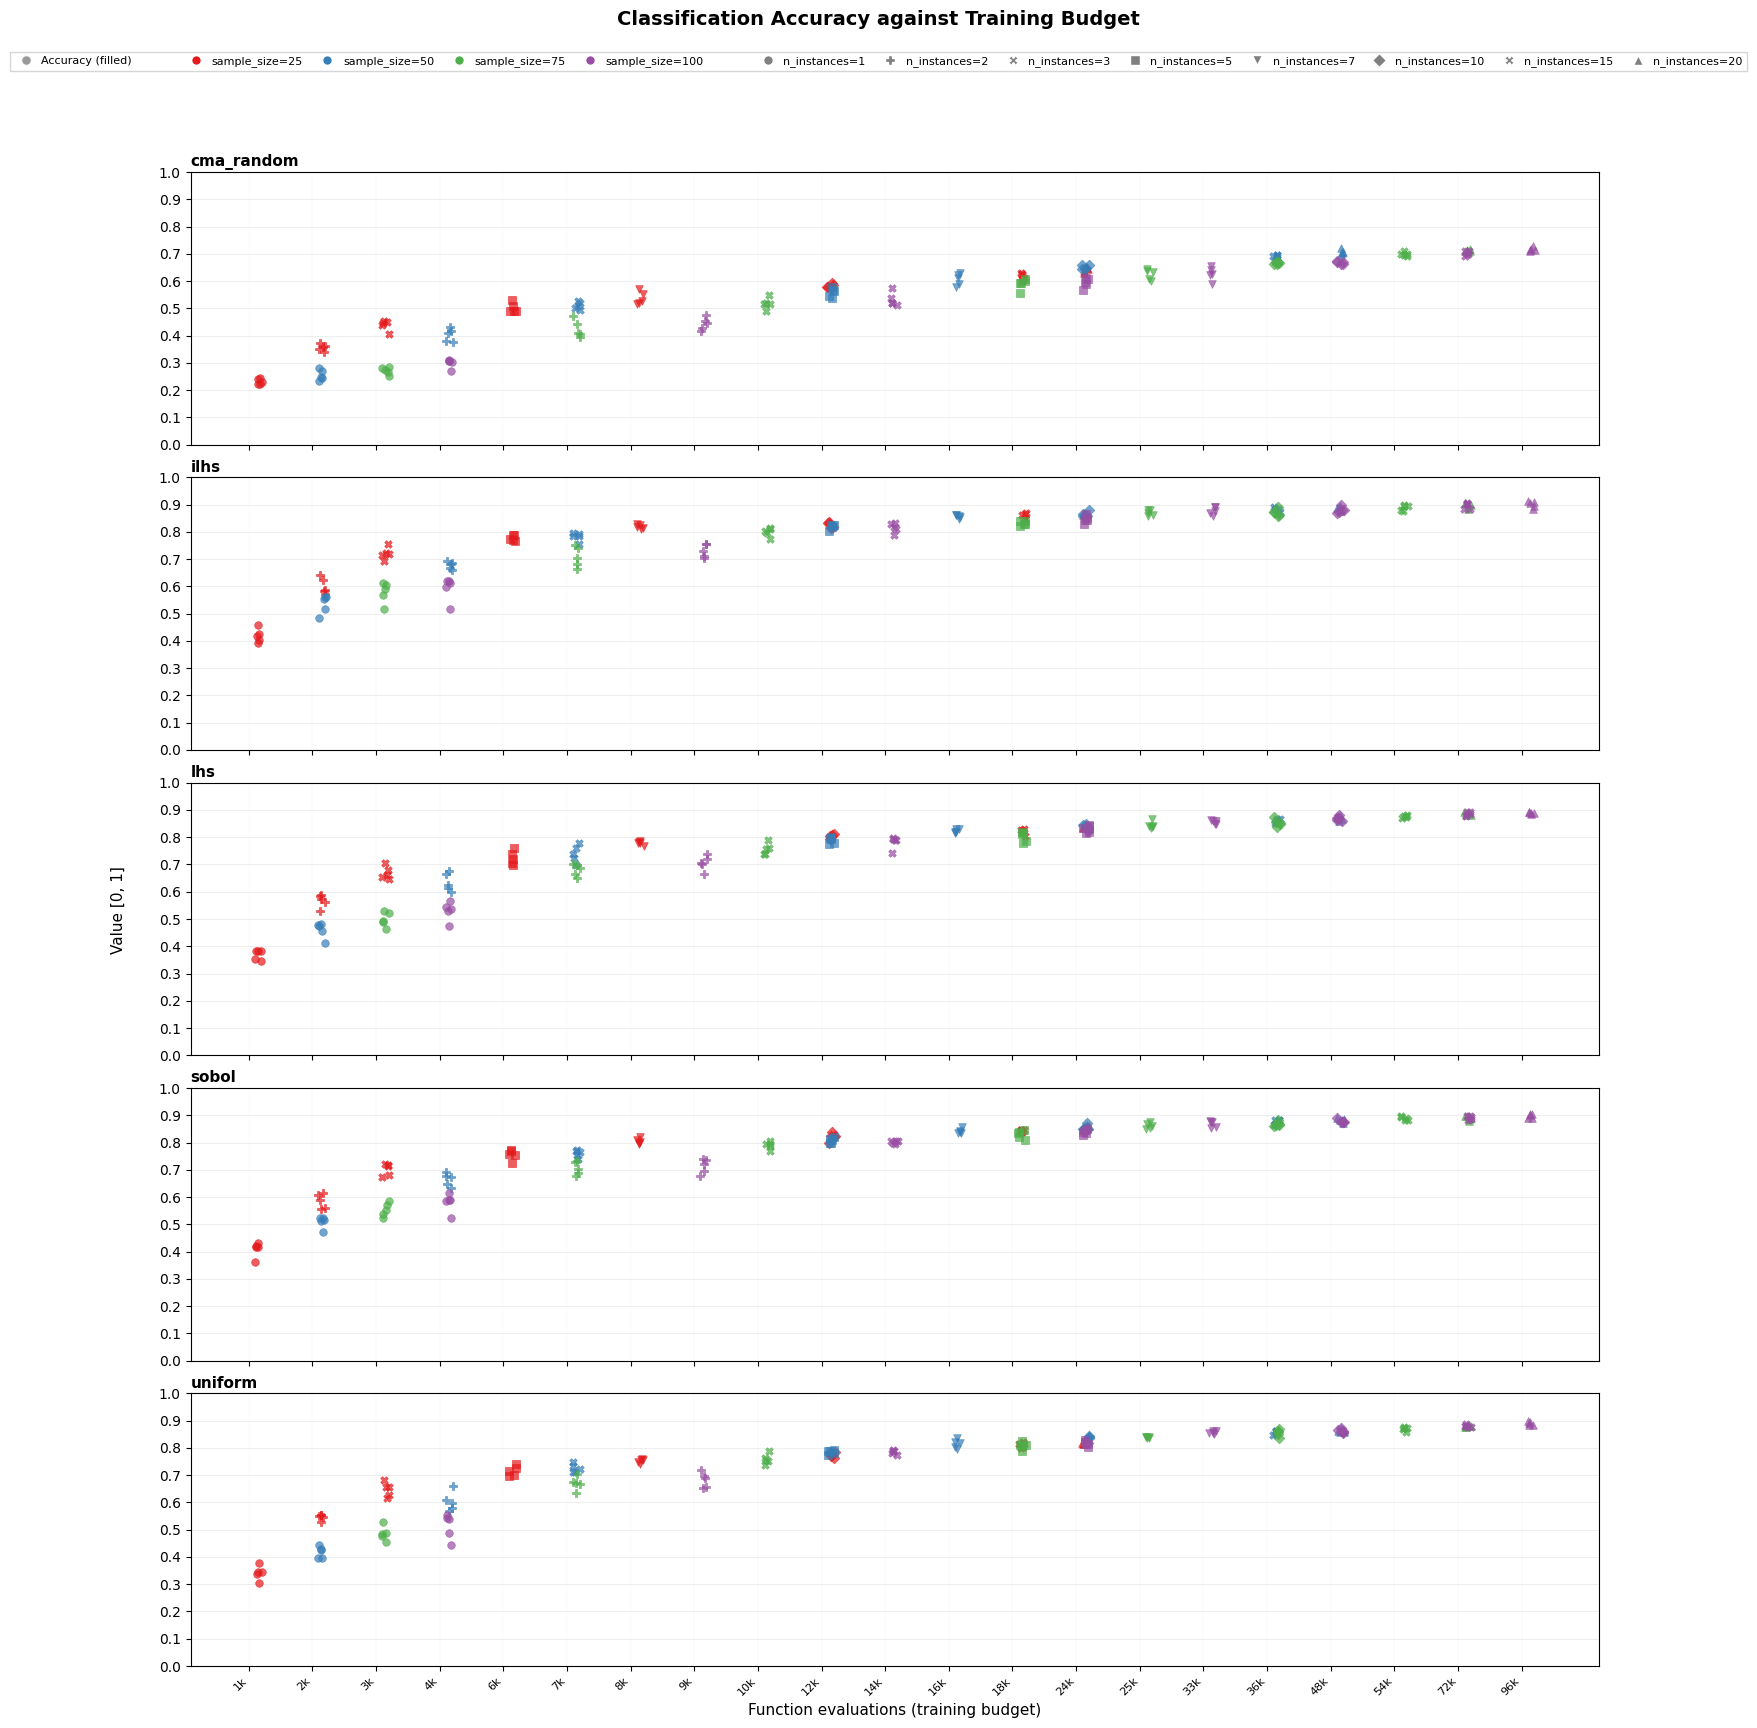

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [8]:
from ela_table_helper import *
plot_cv_vs_accuracy(df[df.n_runs_train == 1])
##  instances per function: [1, 5, 10, 20]
## runs per instance [1, 3, 5]

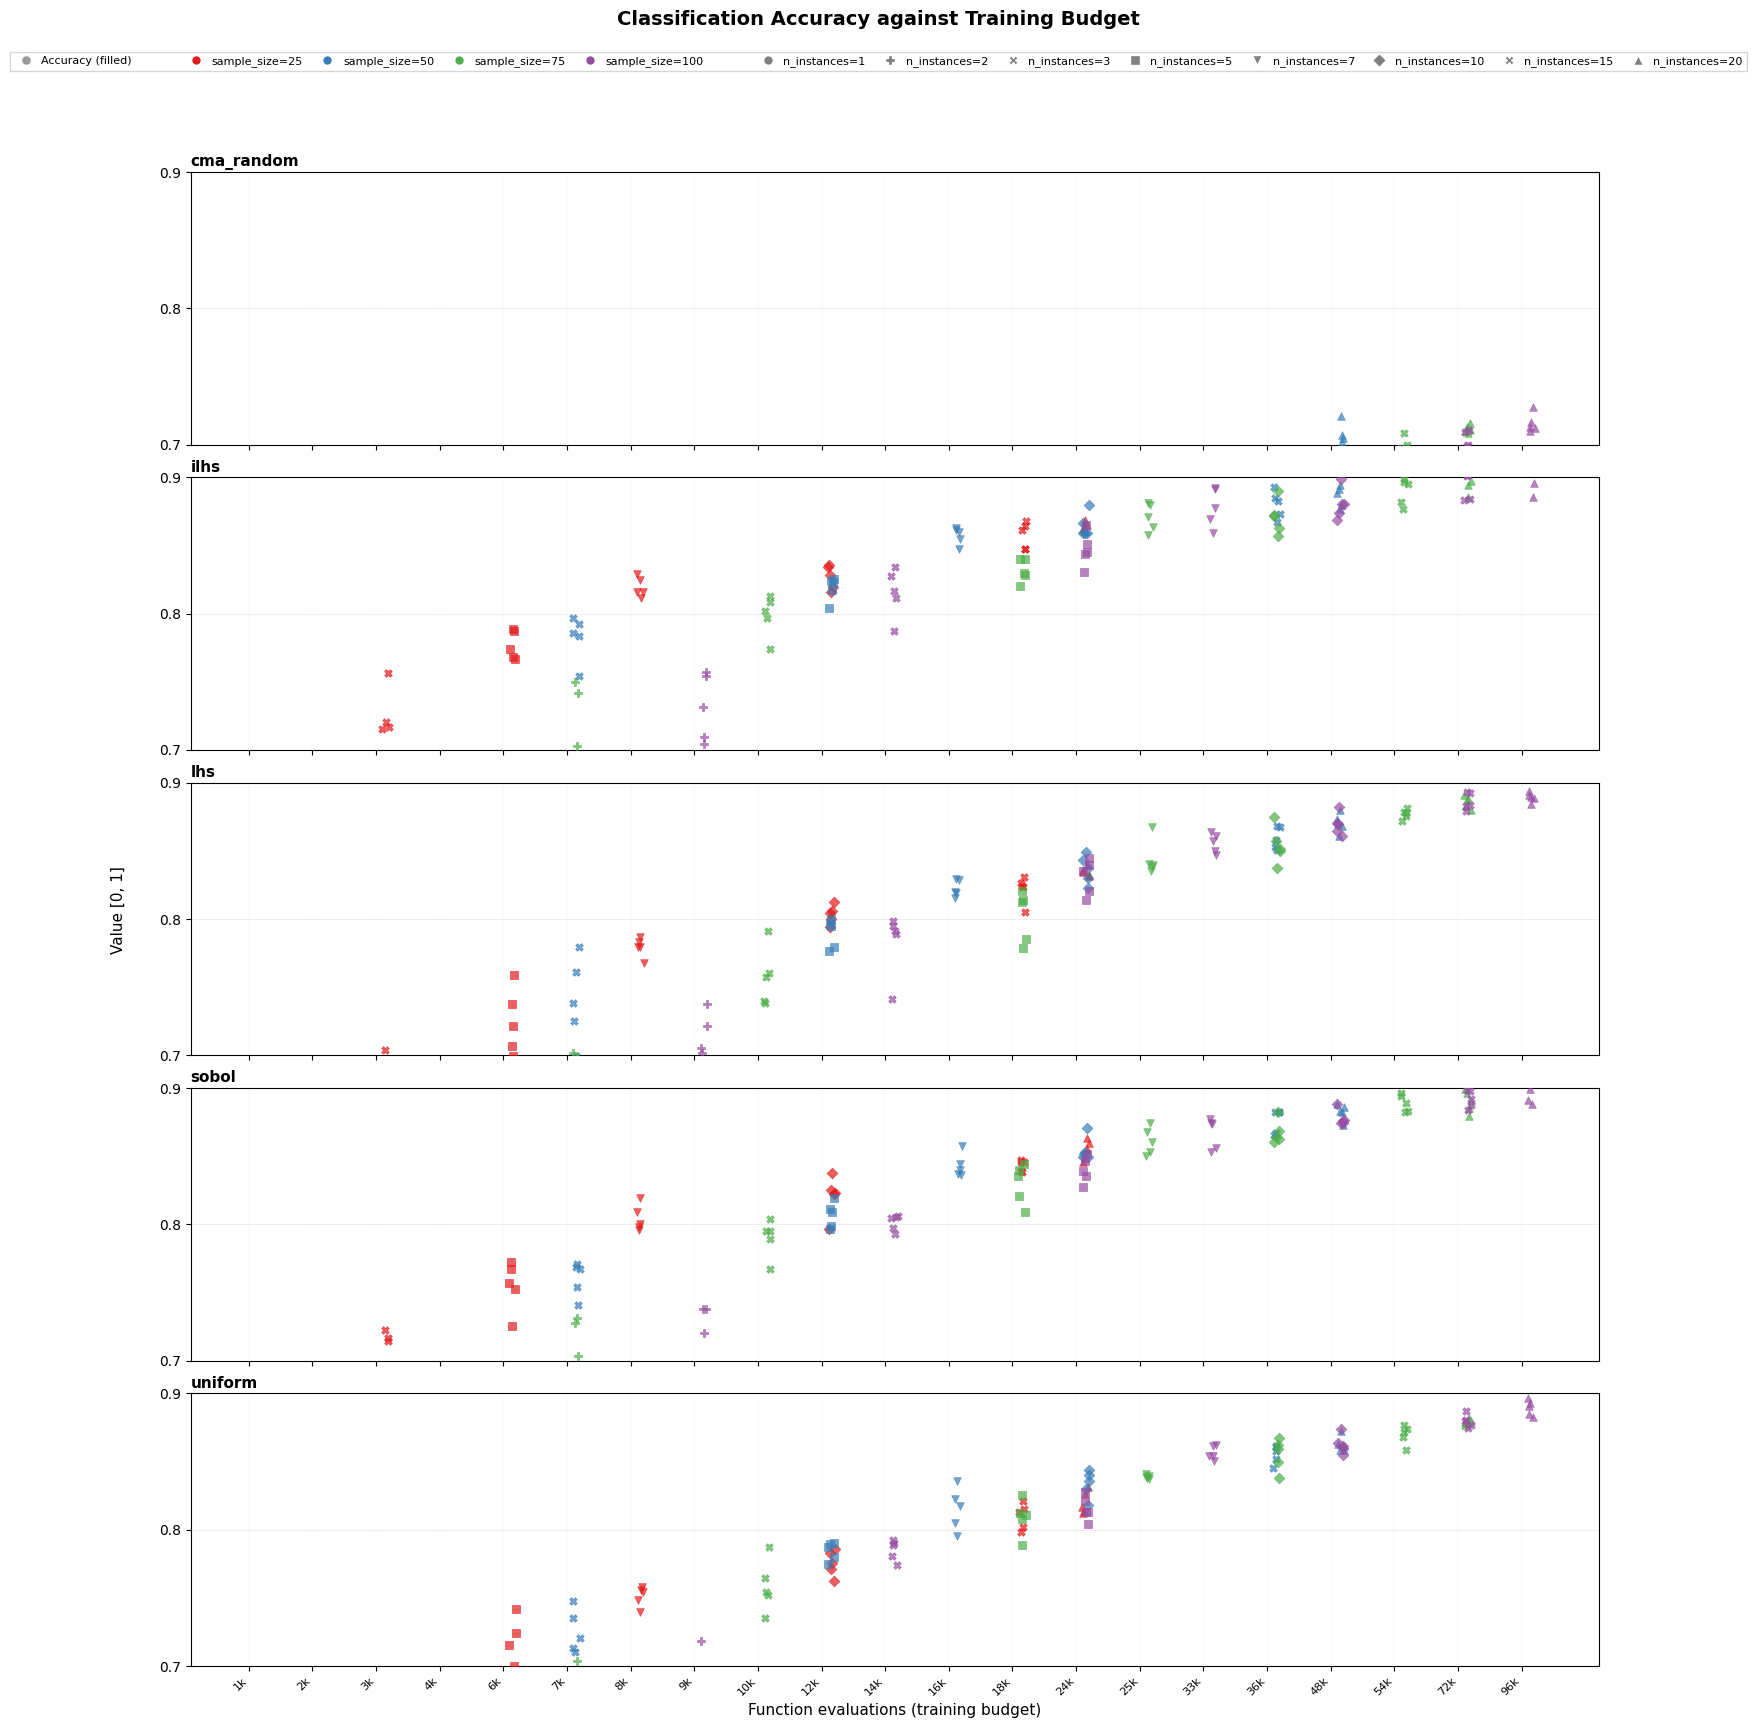

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [9]:
plot_cv_vs_accuracy(df[df.n_runs_train == 1], ylim=(0.7,0.9))

Plot 1: Faceted by strategy ...


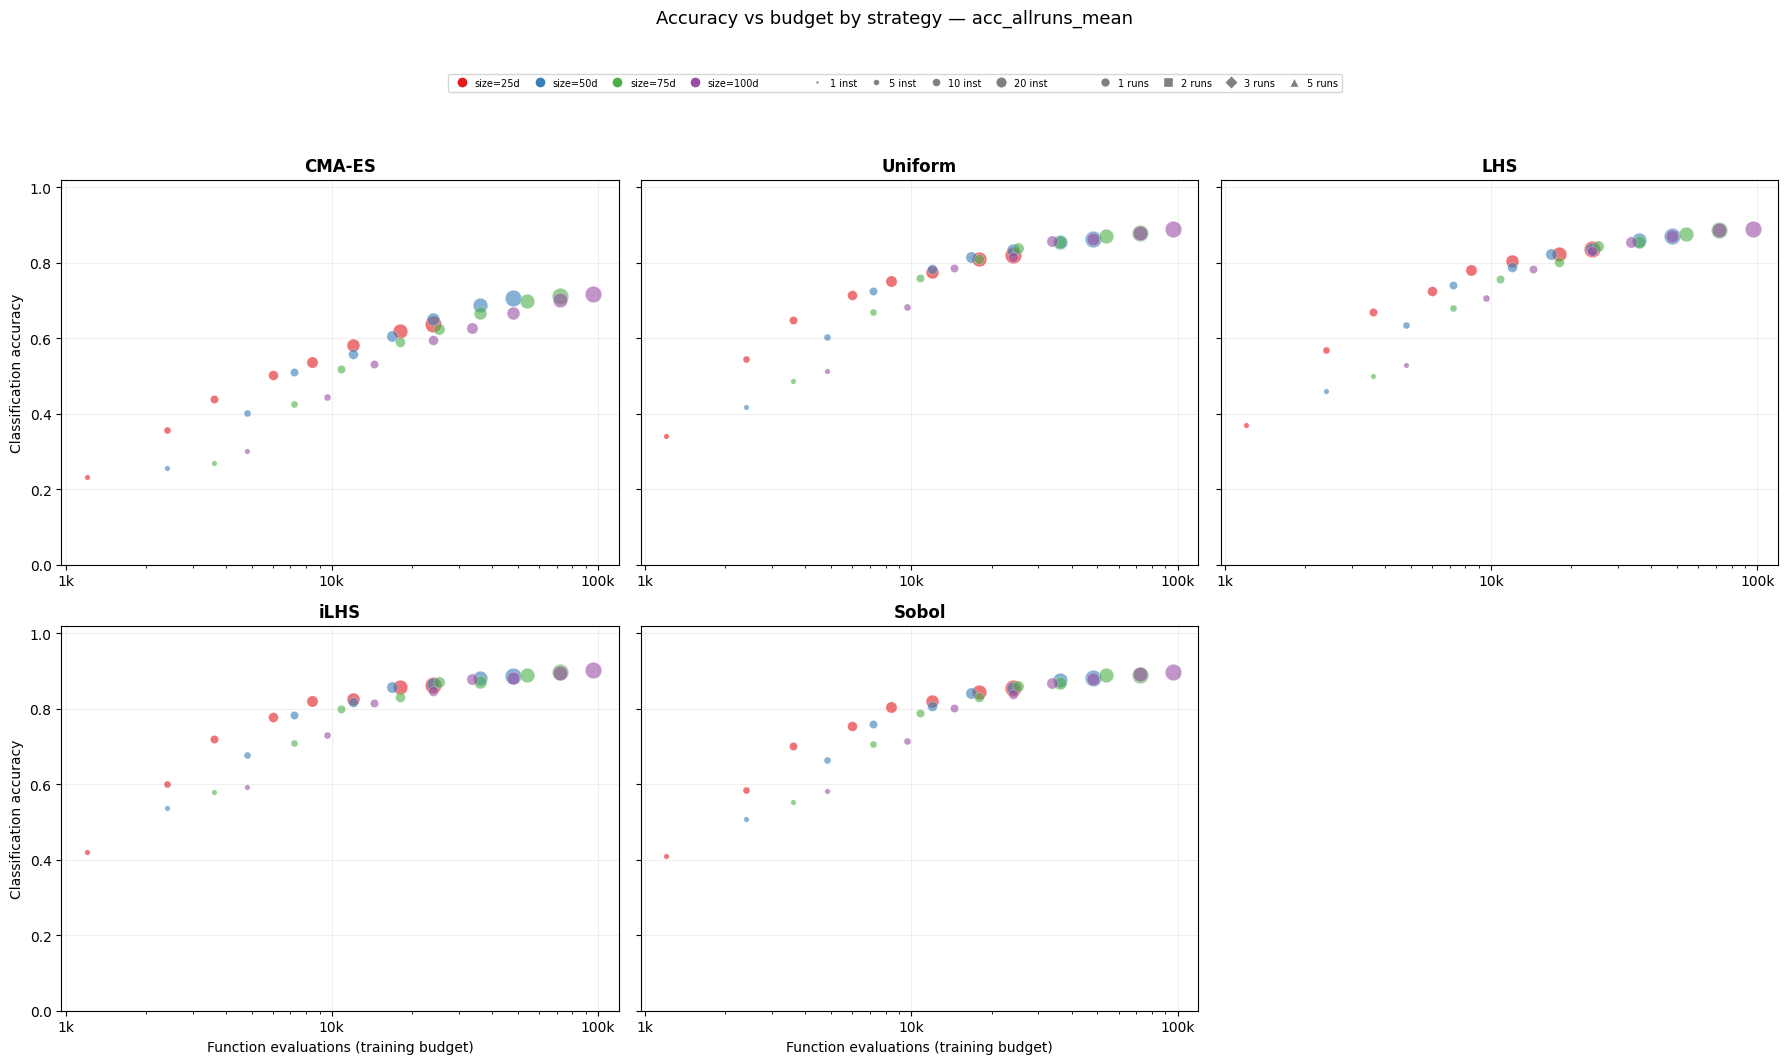

Plot 2: All strategies combined ...


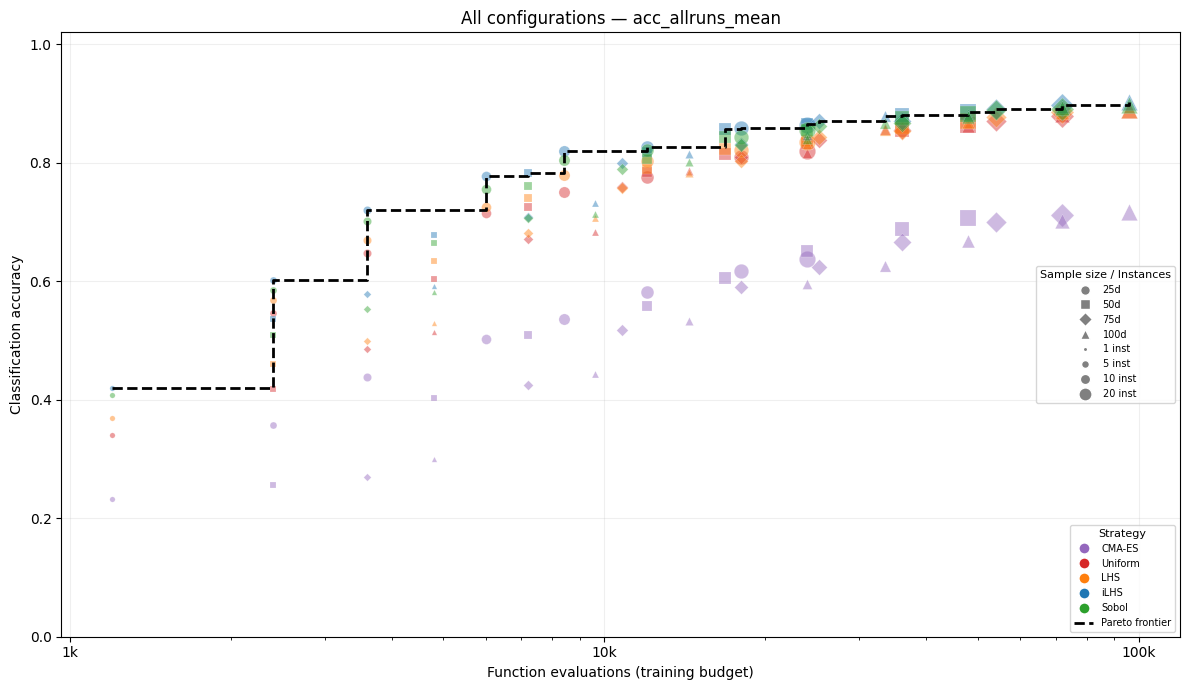

Plot 3: Faceted by sample size ...


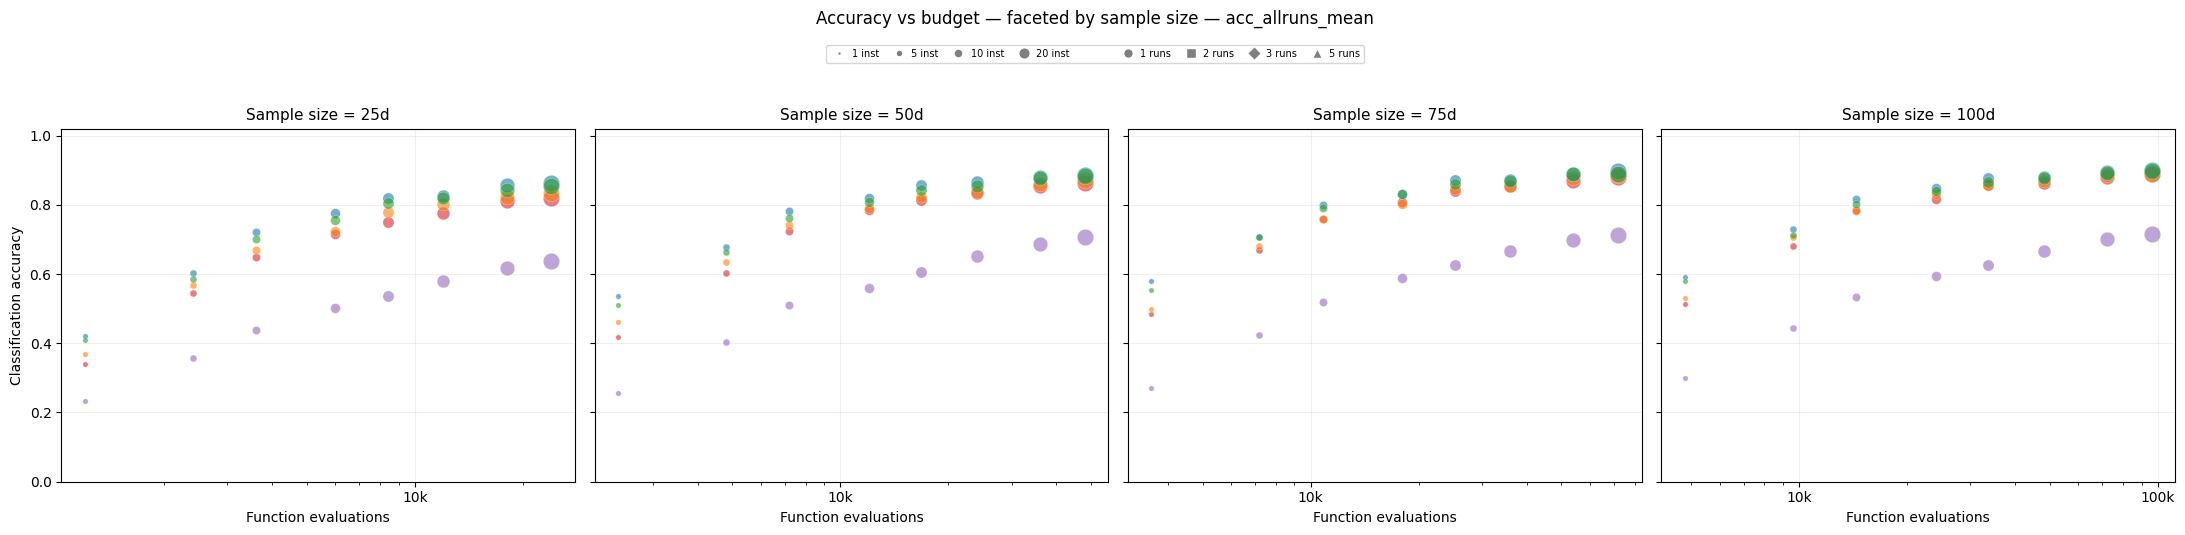

Plot 4: Faceted by n_instances ...


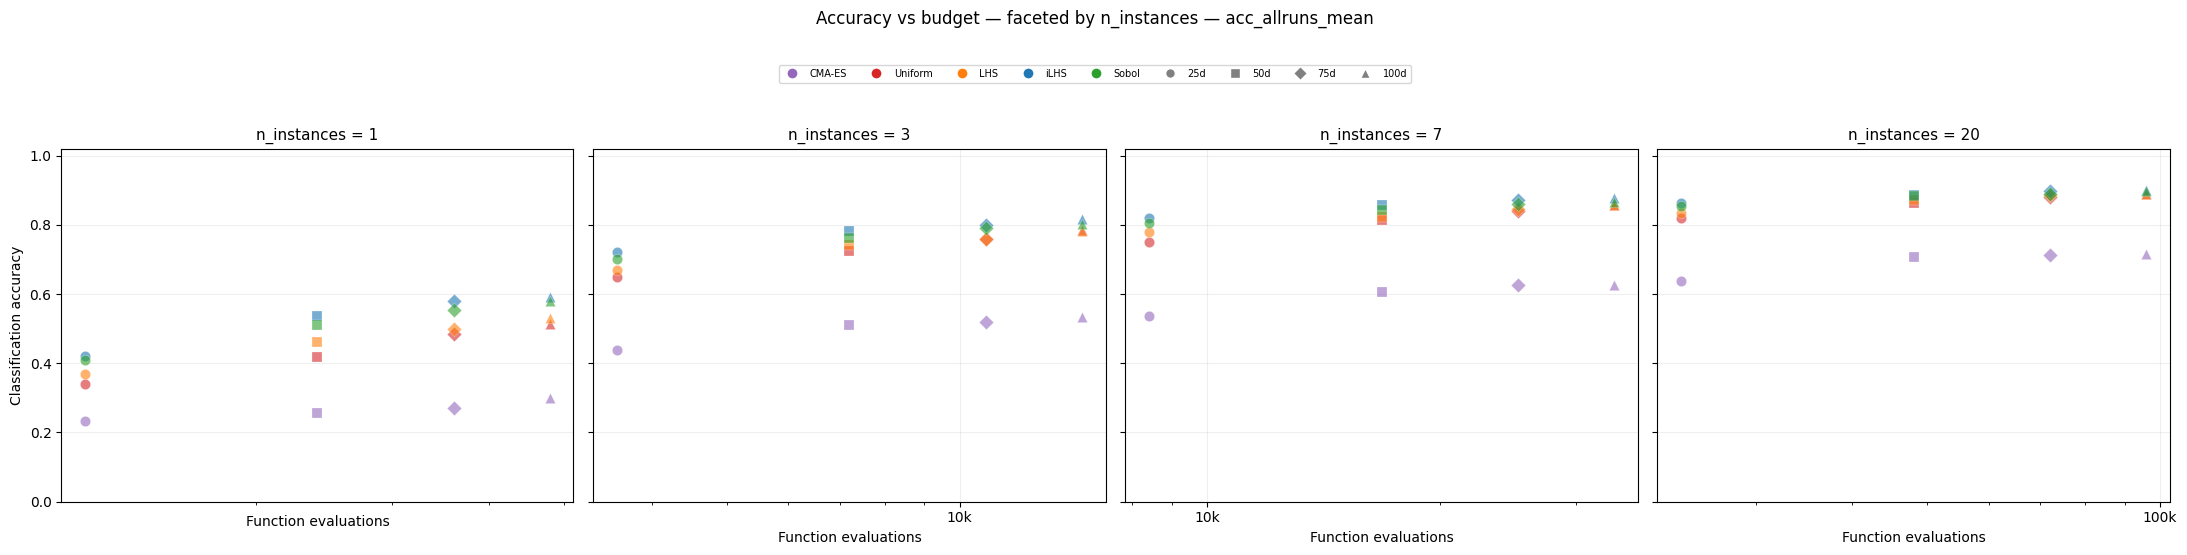

In [10]:
from rq2_accuracy_scatter import *

# All four plots
run_all(fold_agg_df[fold_agg_df.n_runs_train == 1], metric="acc_allruns_mean")

In [11]:
# sns.set_style("darkgrid")
# sns.catplot(data=df[(df.sampling_strategy == "sobol") & (df.n_runs_train == 3)], x="sample_size_per_dim", y="accuracy_allruns", hue="n_instances_train", kind="bar", aspect=5, palette="viridis")

In [12]:
df[df.n_feval_train == 24000][["sample_size_per_dim", "n_instances_train", "n_runs_train"]].value_counts()


sample_size_per_dim  n_instances_train  n_runs_train
25                   10                 2               25
                     20                 1               25
50                   2                  5               25
                     5                  2               25
                     10                 1               25
100                  1                  5               25
                     5                  1               25
Name: count, dtype: int64

In [13]:
# df[df.n_feval_train == 36000][columns].sort_values(by=["accuracy_allruns"], ascending=False)
df[df.n_feval_train == 36000][["sample_size_per_dim", "n_instances_train", "n_runs_train"]].value_counts()


sample_size_per_dim  n_instances_train  n_runs_train
25                   10                 3               25
                     15                 2               25
50                   3                  5               25
                     5                  3               25
                     15                 1               25
75                   2                  5               25
                     5                  2               25
                     10                 1               25
Name: count, dtype: int64

In [14]:
df[df.n_feval_train == 48000][["sample_size_per_dim", "n_instances_train", "n_runs_train"]].value_counts()


sample_size_per_dim  n_instances_train  n_runs_train
25                   20                 2               25
50                   10                 2               25
                     20                 1               25
100                  2                  5               25
                     5                  2               25
                     10                 1               25
Name: count, dtype: int64

In [15]:
df[df.n_feval_train == 72000][["sample_size_per_dim", "n_instances_train", "n_runs_train"]].value_counts()
# df[df.n_feval_train == 14400][columns].sort_values(by=["accuracy_allruns_mean"], ascending=False)

sample_size_per_dim  n_instances_train  n_runs_train
25                   20                 3               25
50                   10                 3               25
                     15                 2               25
75                   10                 2               25
                     20                 1               25
100                  3                  5               25
                     5                  3               25
                     15                 1               25
Name: count, dtype: int64

In [16]:
# df[df.n_feval_train == 96000].sort_values(by=["accuracy_allruns_mean"], ascending=False)
df.groupby(["sampling_strategy", "sample_size_per_dim","n_instances_train"])[columns].apply(lambda g: g.sort_values(by="accuracy_allruns", ascending=False).head(1))
df.groupby(["sampling_strategy", "sample_size_per_dim","n_instances_train", "n_runs_train"])[columns].apply(lambda g: g["accuracy_allruns"].mean())



sampling_strategy  sample_size_per_dim  n_instances_train  n_runs_train
cma_random         25                   1                  1               0.232486
                                                           2               0.360743
                                                           3               0.430094
                                                           5               0.476313
                                        2                  1               0.356903
                                                                             ...   
uniform            100                  15                 5               0.903306
                                        20                 1               0.889521
                                                           2               0.900847
                                                           3               0.903406
                                                           5               0.908115
Leng

In [17]:
import seaborn as sns
# sns.lineplot(data=df[df.sampling_strategy == "sobol"], x="accuracy_allruns_mean", y="cv_instance_median_mean")

In [18]:
# # Most efficient config per strategy (cheapest within 1% of best)
# for s in df["sampling_strategy"].unique():
#     sub = df[df["sampling_strategy"] == s]
#     threshold = sub["accuracy_allruns_mean"].max() - 0.01
#     print(sub[sub["accuracy_allruns_mean"] >= threshold].sort_values("n_feval_train").iloc[0])
#     print()

In [19]:
df[(df.sampling_strategy == "sobol")]

,dimension,sampling_strategy,sample_size_per_dim,n_instances_train,n_runs_train,n_feval_train,fold,n_features,n_omitted_features,omitted_features,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_median_mean,cv_training_folds_median_median,accuracy_median,accuracy_allruns,consistency
1920,2,sobol,25,1,1,1200,0,40,6,"ela_meta.quad_simple.cond, disp.ratio_mean_02,...",0.240613,0.194634,0.599435,0.348601,NaN,NaN,0.522917,0.429913,0.429913
1921,2,sobol,25,1,1,1200,1,40,6,"ela_meta.quad_simple.cond, disp.ratio_mean_02,...",0.240613,0.194634,0.599435,0.348601,NaN,NaN,0.428646,0.362587,0.362587
1922,2,sobol,25,1,1,1200,2,40,6,"ela_meta.quad_simple.cond, disp.ratio_mean_02,...",0.240613,0.194634,0.599435,0.348601,NaN,NaN,0.502083,0.416302,0.416302
1923,2,sobol,25,1,1,1200,3,40,6,"ela_meta.quad_simple.cond, disp.ratio_mean_02,...",0.240613,0.194634,0.599435,0.348601,NaN,NaN,0.491667,0.415868,0.415868
1924,2,sobol,25,1,1,1200,4,40,6,"ela_meta.quad_simple.cond, disp.ratio_mean_02,...",0.240613,0.194634,0.599435,0.348601,NaN,NaN,0.478646,0.418715,0.418715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,2,sobol,100,20,5,480000,0,40,6,"ela_meta.quad_simple.cond, disp.ratio_mean_02,...",0.130909,0.079522,0.560618,0.229258,NaN,NaN,0.923958,0.921823,0.921823
2556,2,sobol,100,20,5,480000,1,40,6,"ela_meta.quad_simple.cond, disp.ratio_mean_02,...",0.130909,0.079522,0.560618,0.229258,NaN,NaN,0.911979,0.907517,0.907517
2557,2,sobol,100,20,5,480000,2,40,6,"ela_meta.quad_simple.cond, disp.ratio_mean_02,...",0.130909,0.079522,0.560618,0.229258,NaN,NaN,0.924479,0.917500,0.917500
2558,2,sobol,100,20,5,480000,3,40,6,"ela_meta.quad_simple.cond, disp.ratio_mean_02,...",0.130909,0.079522,0.560618,0.229258,NaN,NaN,0.921875,0.911875,0.911875


In [20]:
fold_agg_df["budget_level"] = pd.qcut(
    fold_agg_df["n_feval_train"],
    q=4,
    labels=["low", "medium-low", "medium-high", "high"]
)

### Accuracy as a function of budget

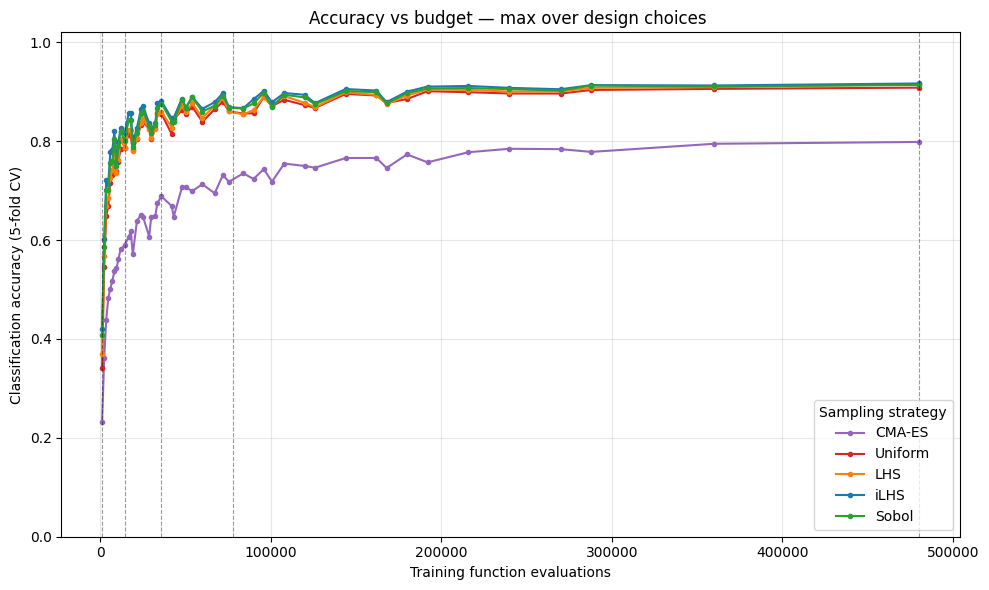

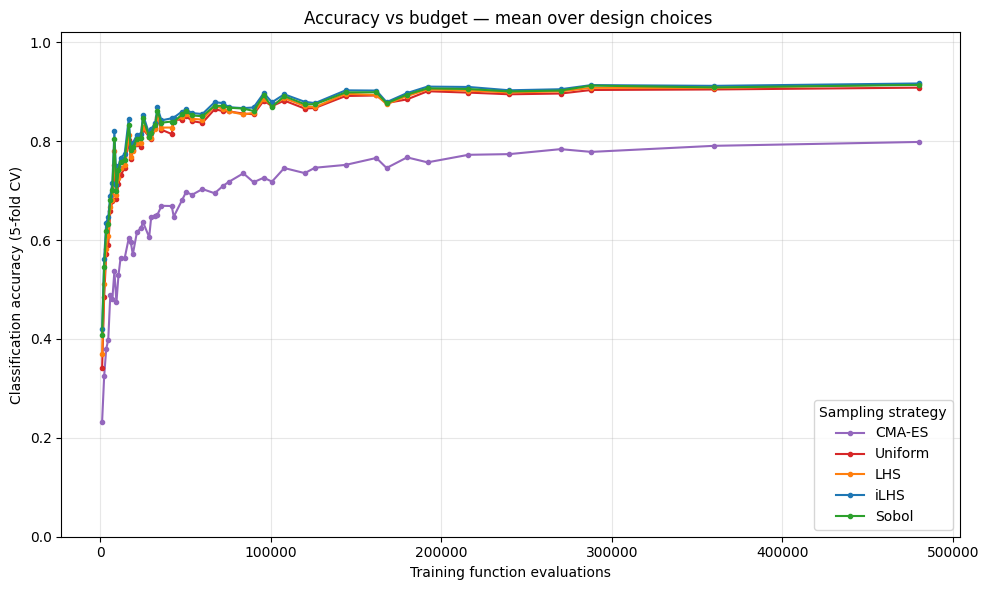

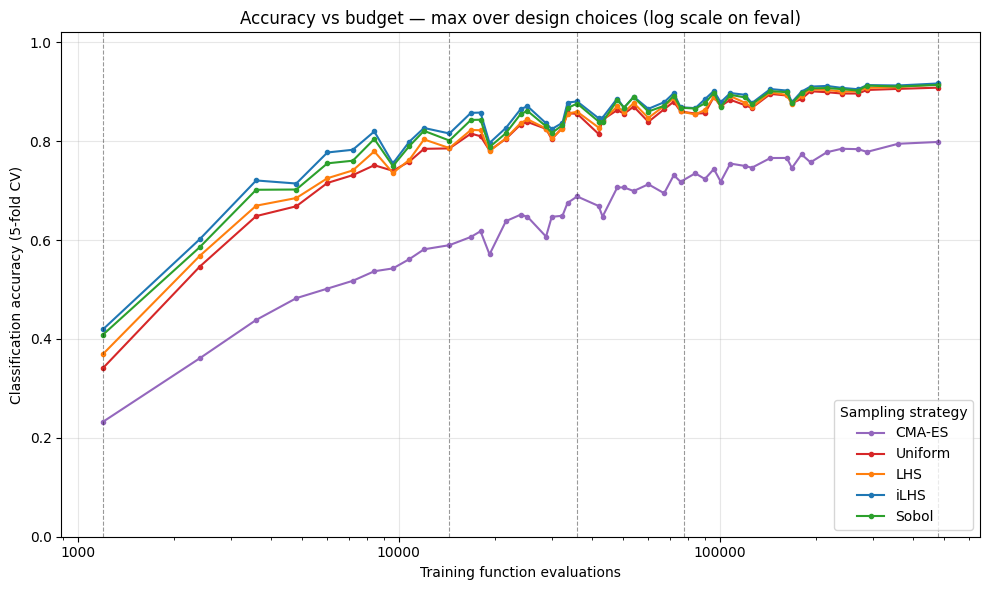

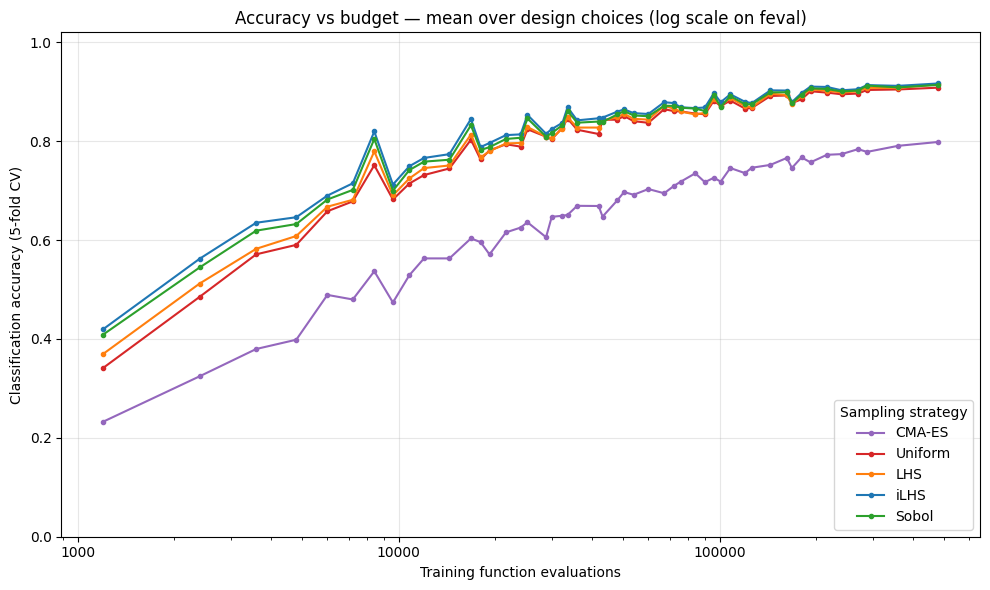

In [21]:
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean")
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4, log_scale=True)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean", log_scale=True)


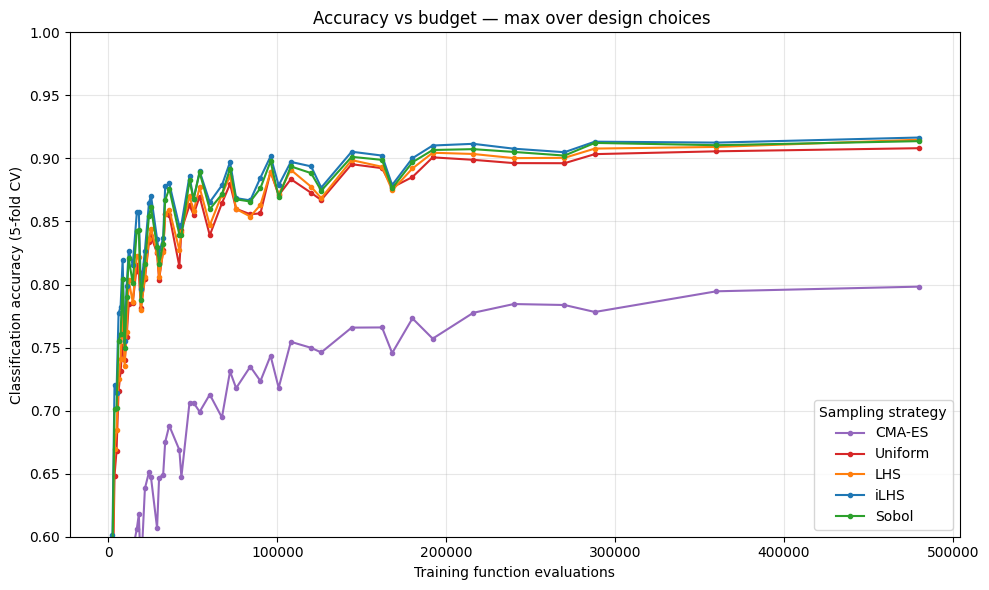

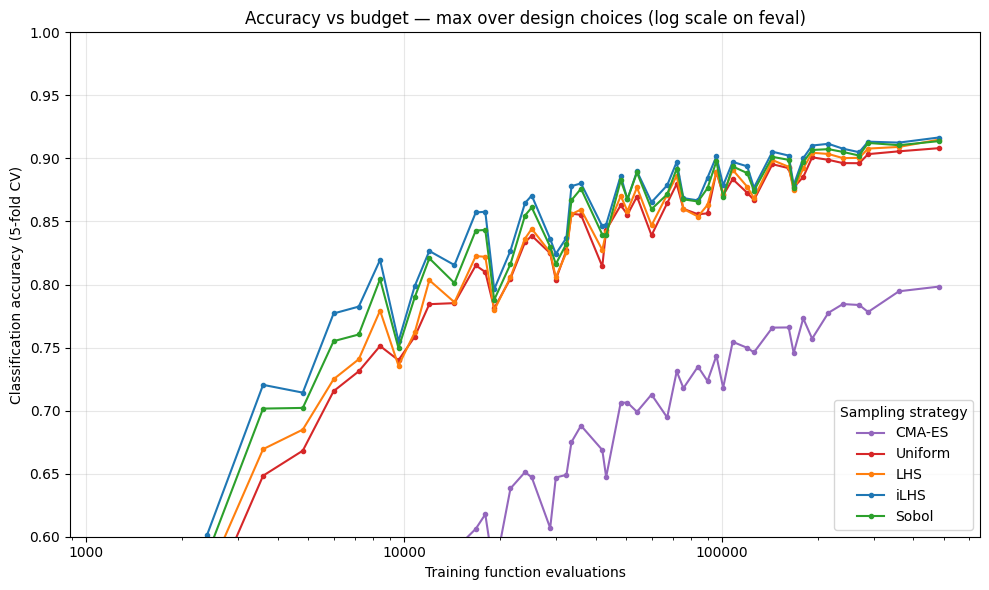

In [22]:
plot_accuracy_vs_budget(fold_agg_df, ylim=(0.6,1.0))
plot_accuracy_vs_budget(fold_agg_df, ylim=(0.6,1.0), log_scale=True)


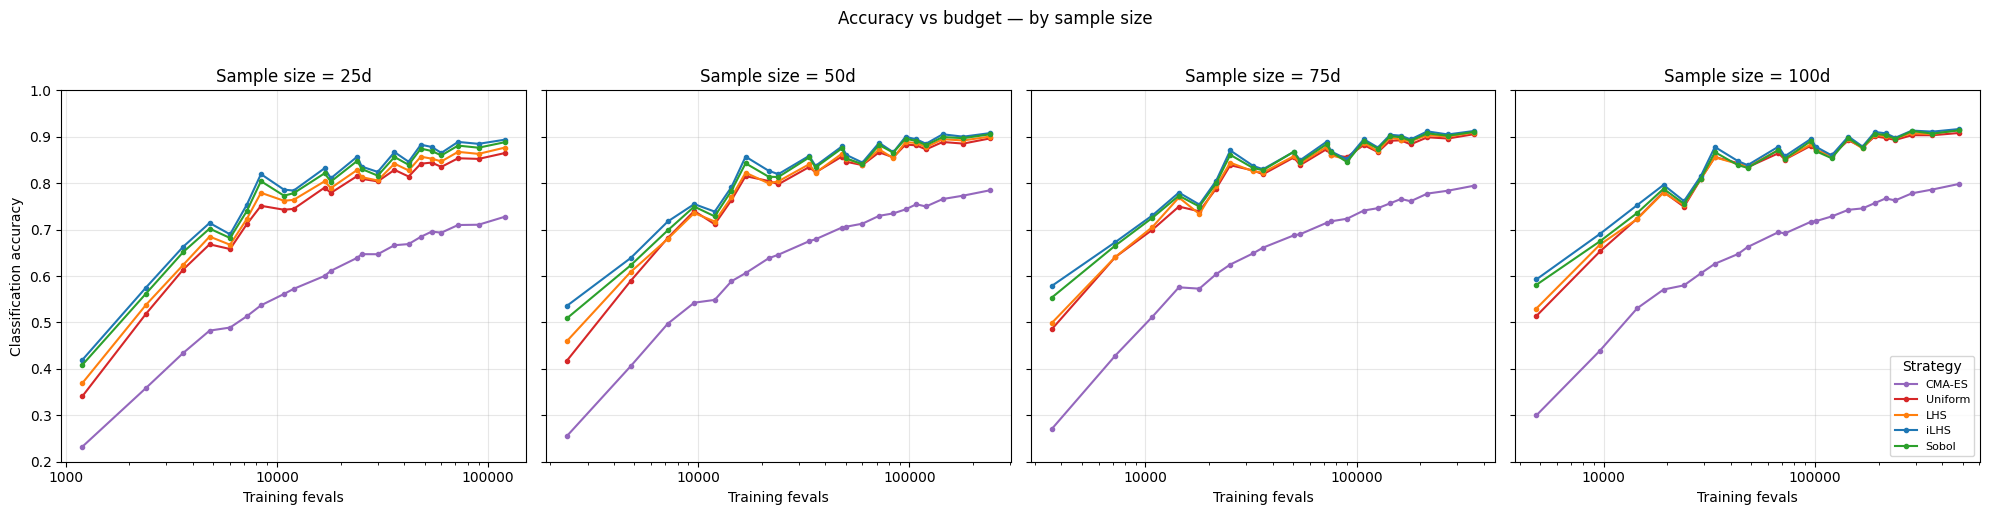

In [23]:
plot_accuracy_vs_budget_faceted(fold_agg_df, ylim = (0.2, 1.0))

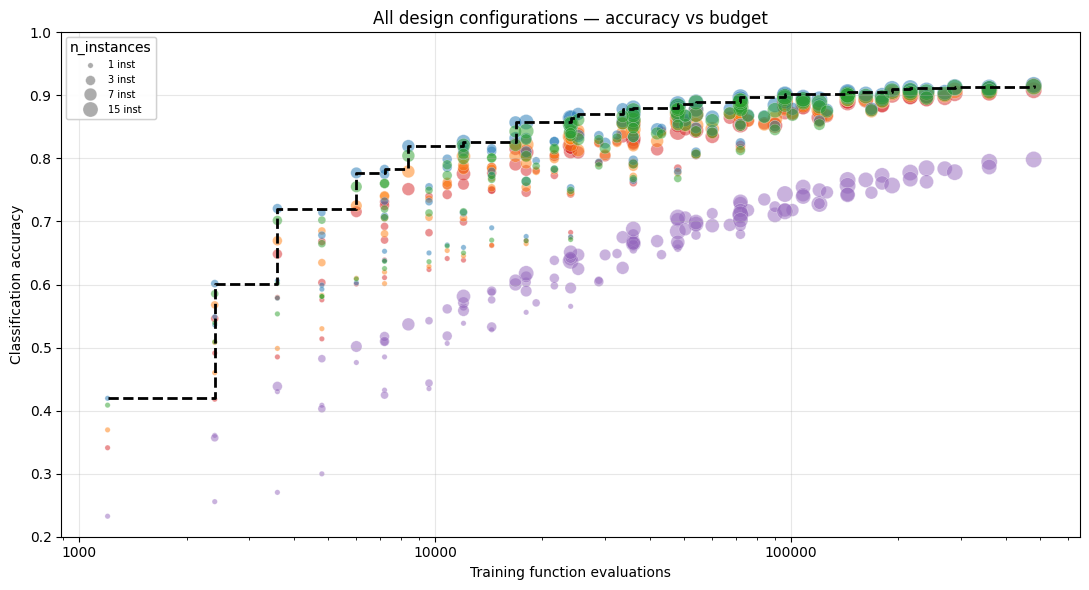

In [24]:
plot_scatter_with_pareto(fold_agg_df, ylim=(0.2,1.0))

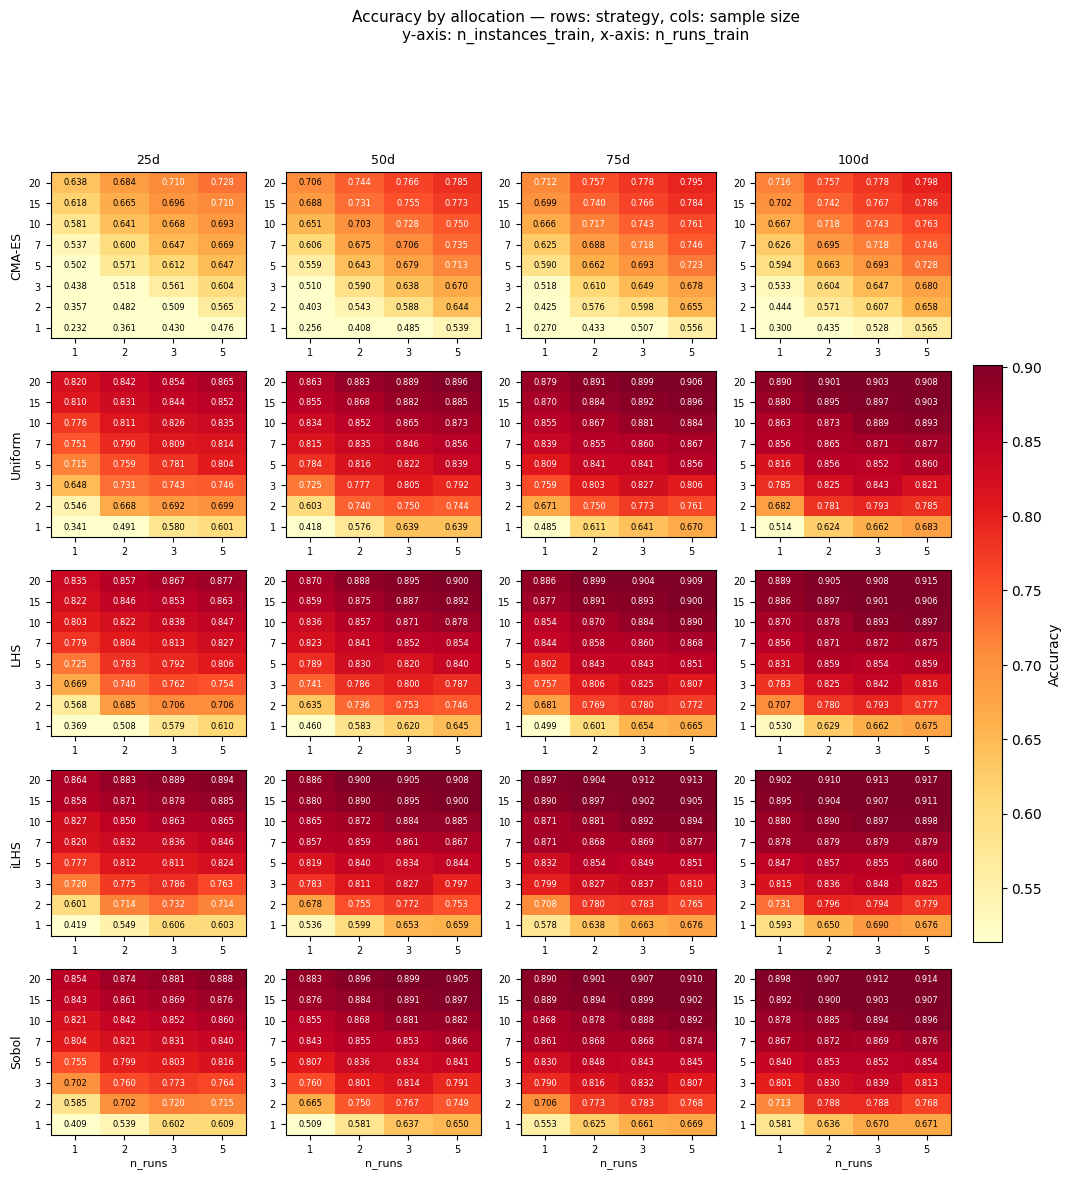

In [25]:
plot_allocation_heatmaps(fold_agg_df)

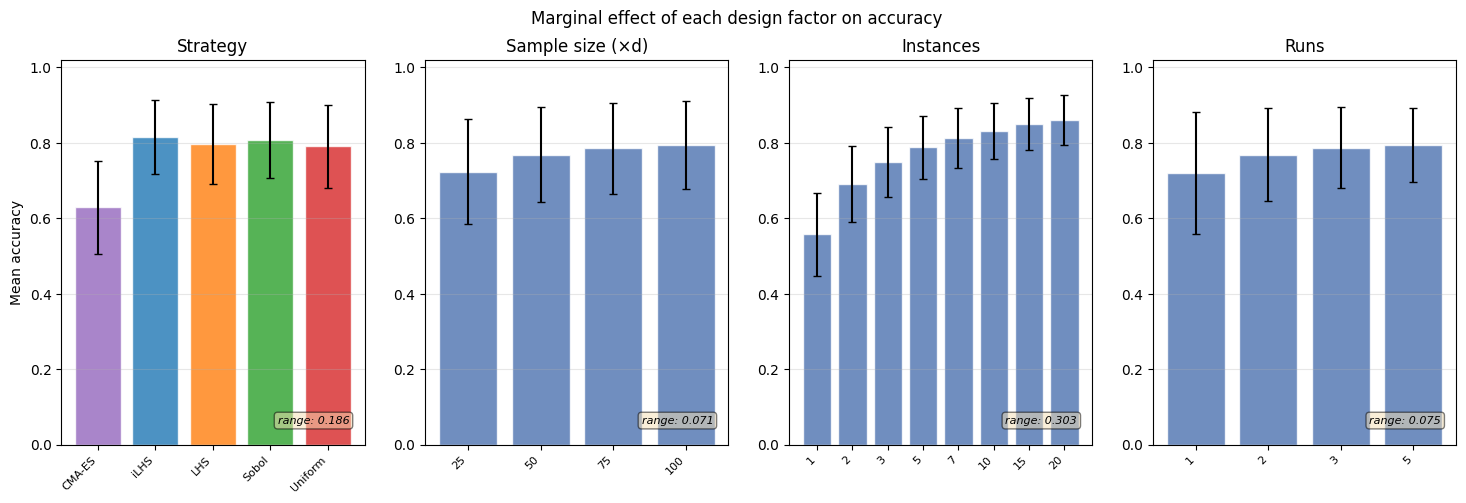

In [26]:
plot_marginal_effects(fold_agg_df)

### Budget-conditioned factor importance

Budget tiers (4):
  (1199.999, 14400.0]: 180 configs
  (14400.0, 36000.0]: 170 configs
  (36000.0, 77700.0]: 130 configs
  (77700.0, 480000.0]: 160 configs

        budget_tier              factor factor_label   eta_sq  marginal_range  n_rows  n_levels
(1199.999, 14400.0]   sampling_strategy     Strategy 0.409871        0.227703     180         5
(1199.999, 14400.0] sample_size_per_dim  Sample size 0.002431        0.017447     180         4
(1199.999, 14400.0]   n_instances_train    Instances 0.351321        0.216831     180         6
(1199.999, 14400.0]        n_runs_train         Runs 0.011457        0.029287     180         4
 (14400.0, 36000.0]   sampling_strategy     Strategy 0.737709        0.194551     170         5
 (14400.0, 36000.0] sample_size_per_dim  Sample size 0.019877        0.032929     170         4
 (14400.0, 36000.0]   n_instances_train    Instances 0.197853        0.161692     170         8
 (14400.0, 36000.0]        n_runs_train         Runs 0.119197        0.0818

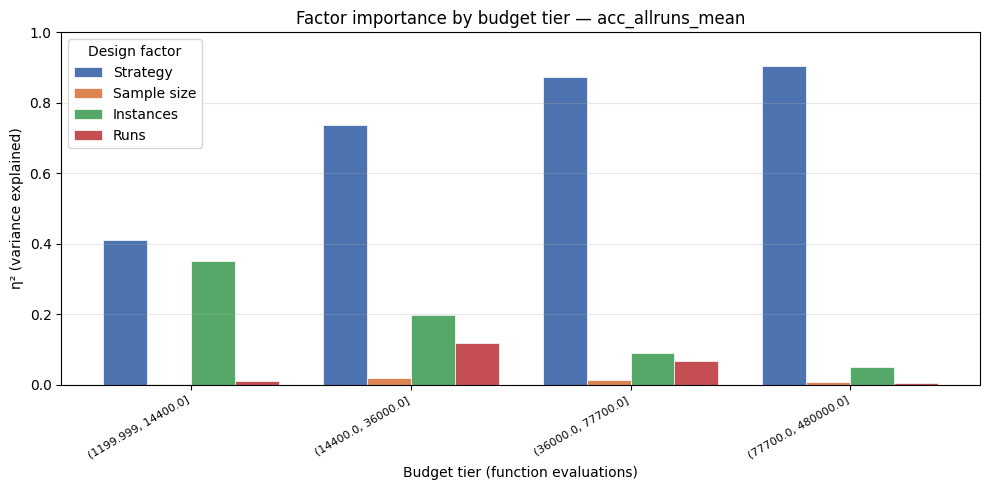

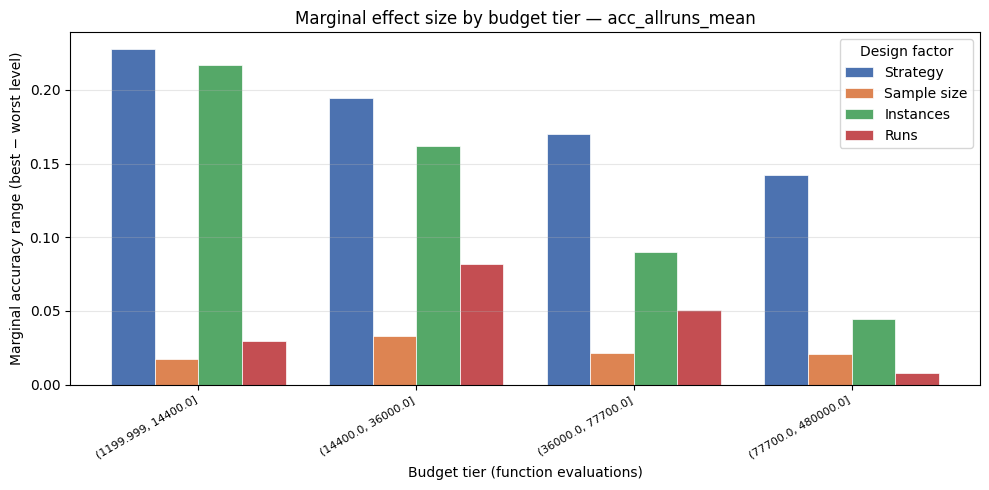

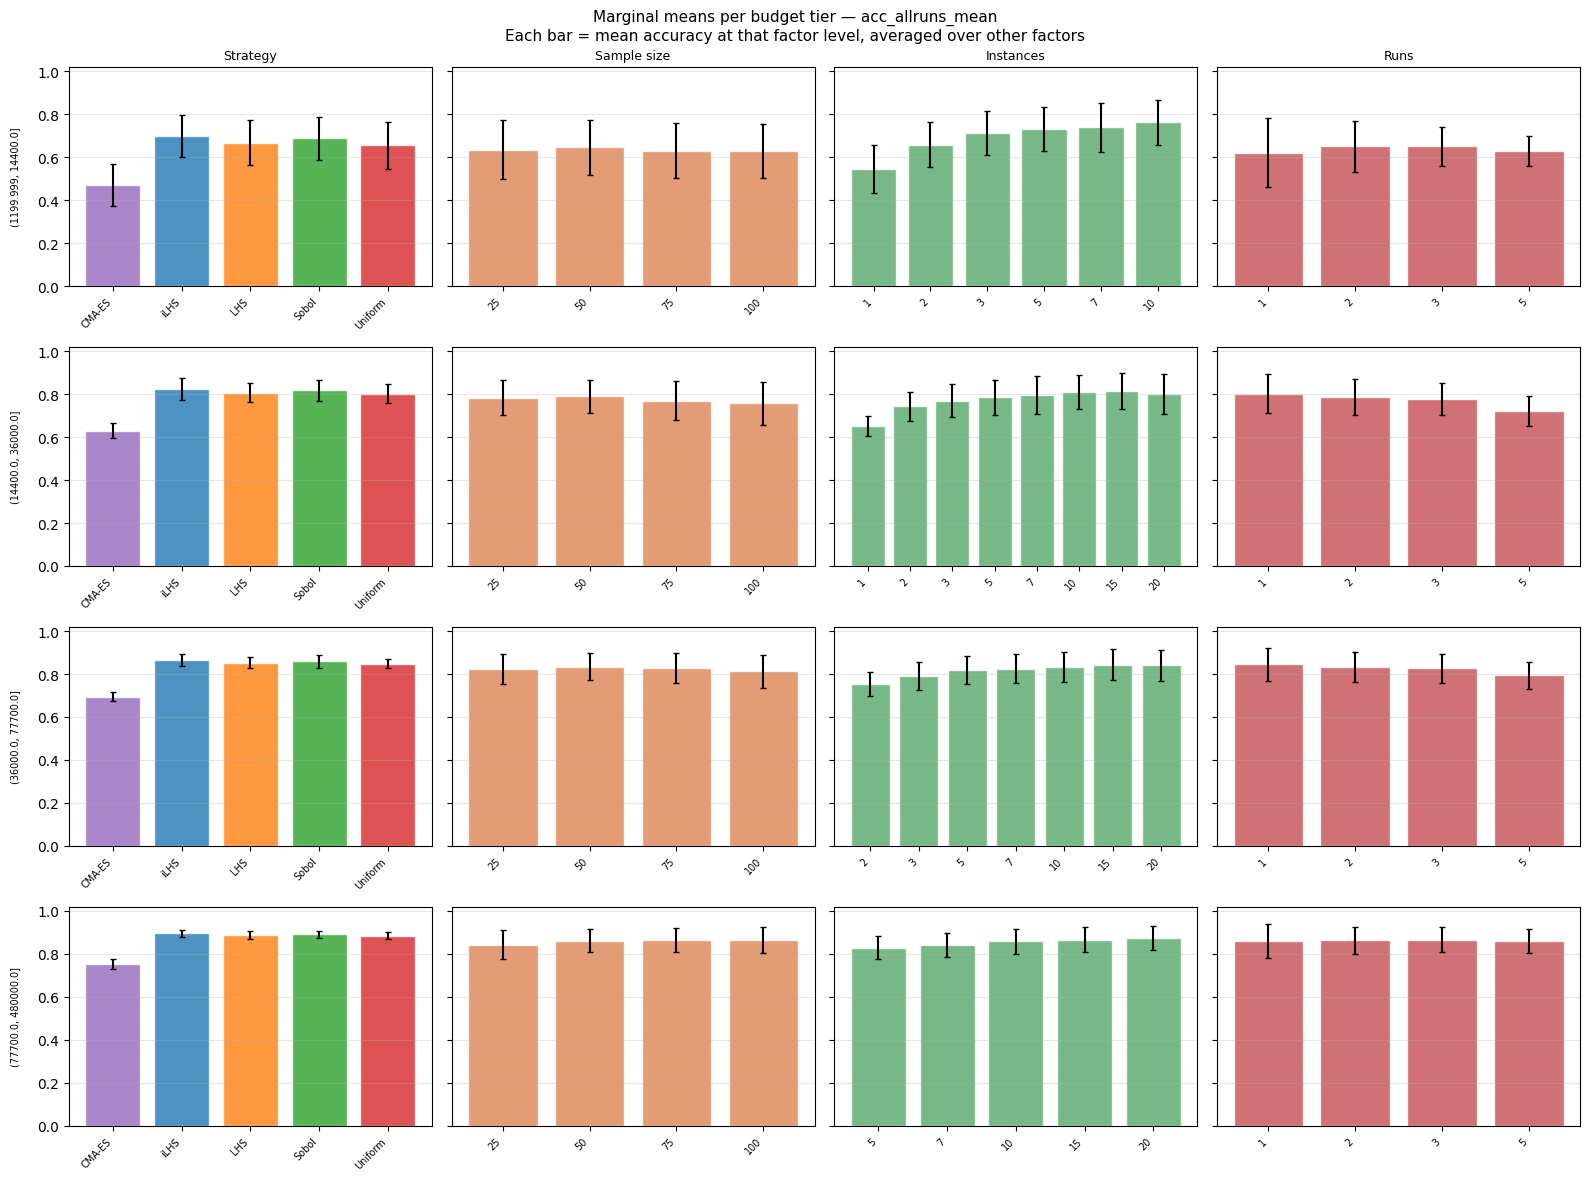

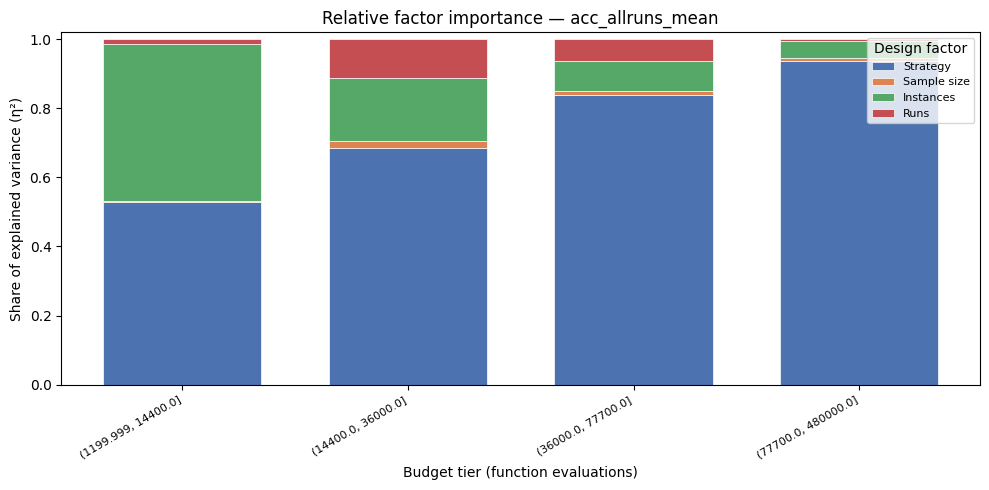

In [27]:
from rq2_factor_importance import *
imp_df = run_all(fold_agg_df, metric="acc_allruns_mean")

Omitted strategies: {'cma_random'}
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Budget tiers (4):
  (1199.999, 14400.0]: 144 configs
  (14400.0, 36000.0]: 136 configs
  (36000.0, 77700.0]: 104 configs
  (77700.0, 480000.0]: 128 configs

        budget_tier              factor factor_label   eta_sq  marginal_range  n_rows  n_levels
(1199.999, 14400.0]   sampling_strategy     Strategy 0.027679        0.044118     144         4
(1199.999, 14400.0] sample_size_per_dim  Sample size 0.002239        0.011786     144         4
(1199.999, 14400.0]   n_instances_train    Instances 0.643879        0.226804     144         6
(1199.999, 14400.0]        n_runs_train         Runs 0.011773        0.035800     144         4
 (14400.0, 36000.0]   sampling_strategy     Strategy 0.034685        0.022029     136         4
 (14400.0, 36000.0] sample_size_per_dim  Sample size 0.049113        0.026109     136         4
 (14400.0, 36000.0]   n_instances_train    Instances 0.821522        0.178062     136   

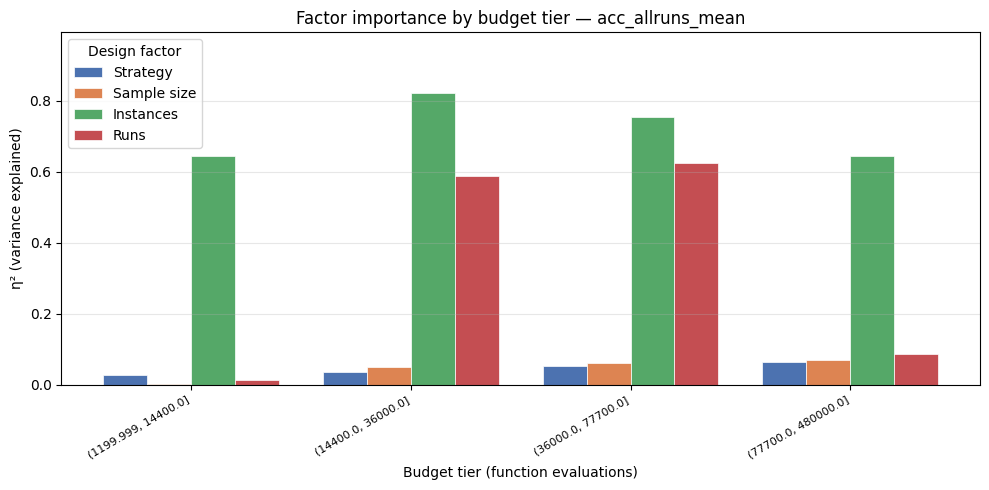

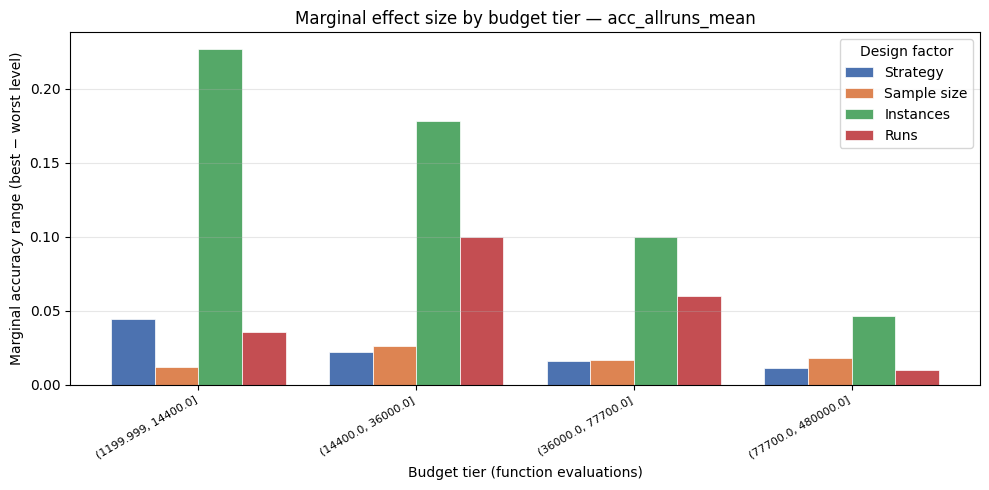

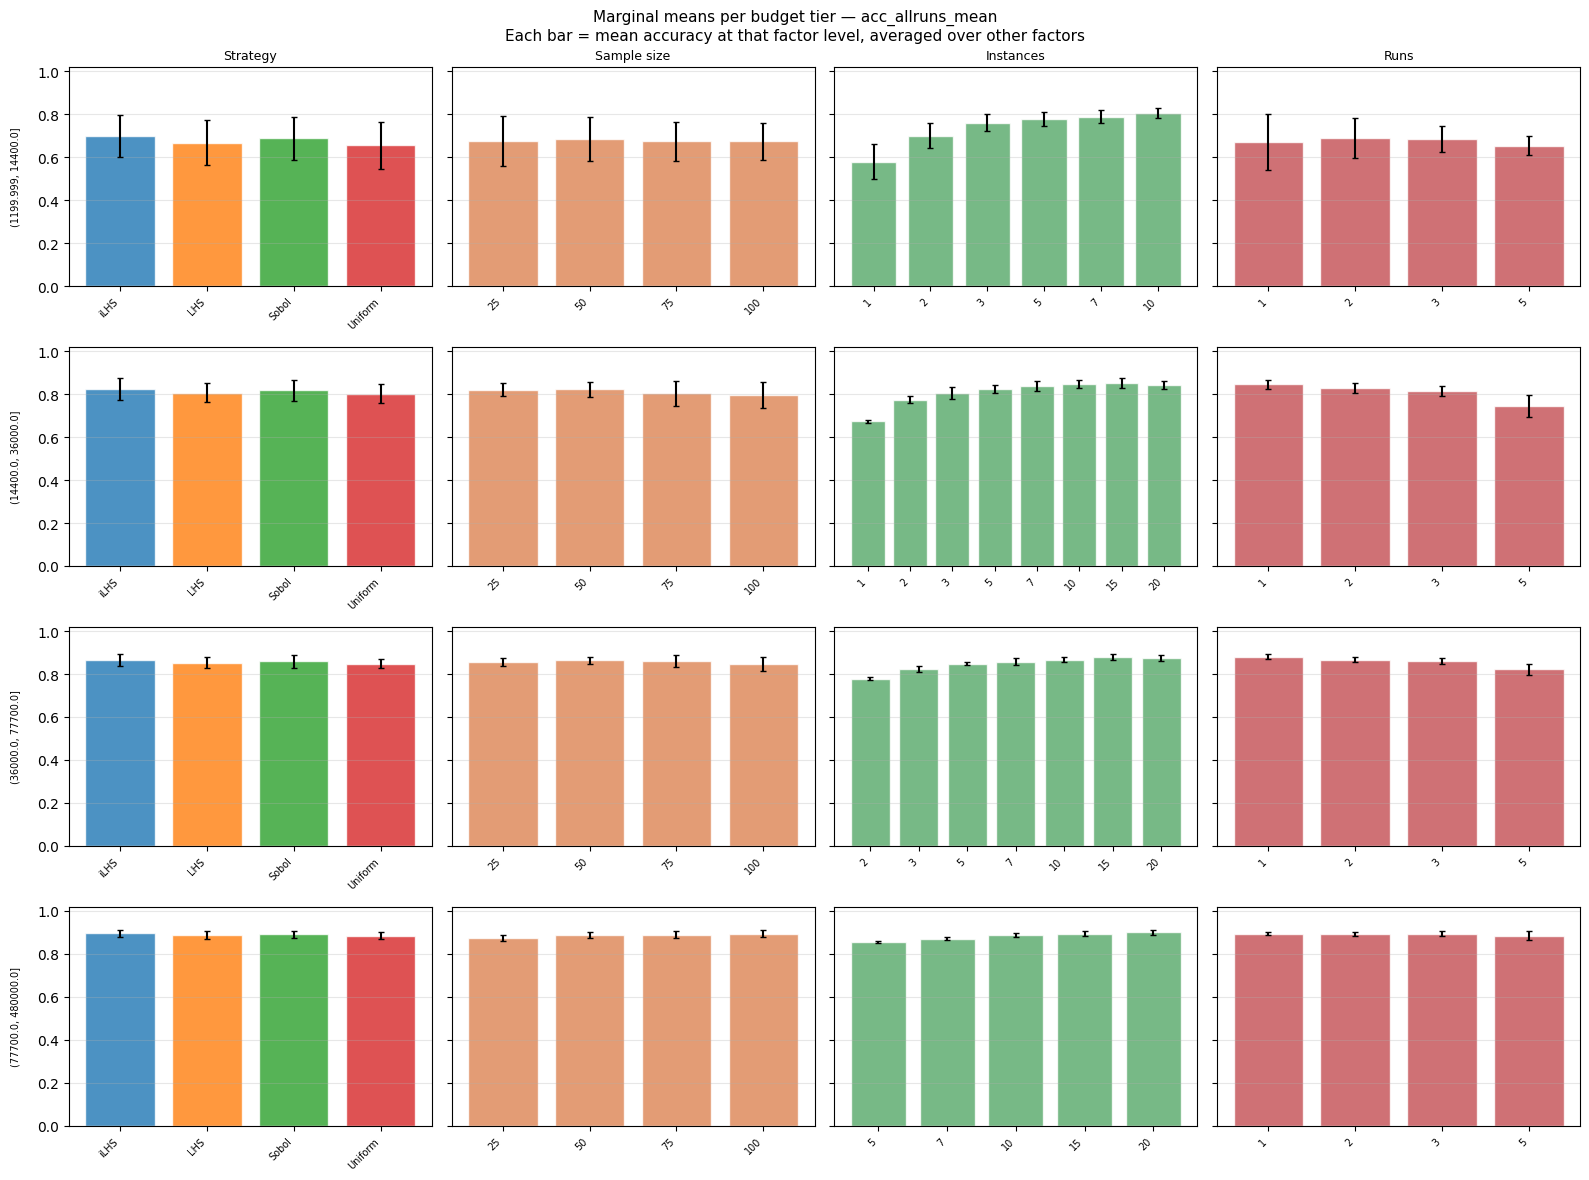

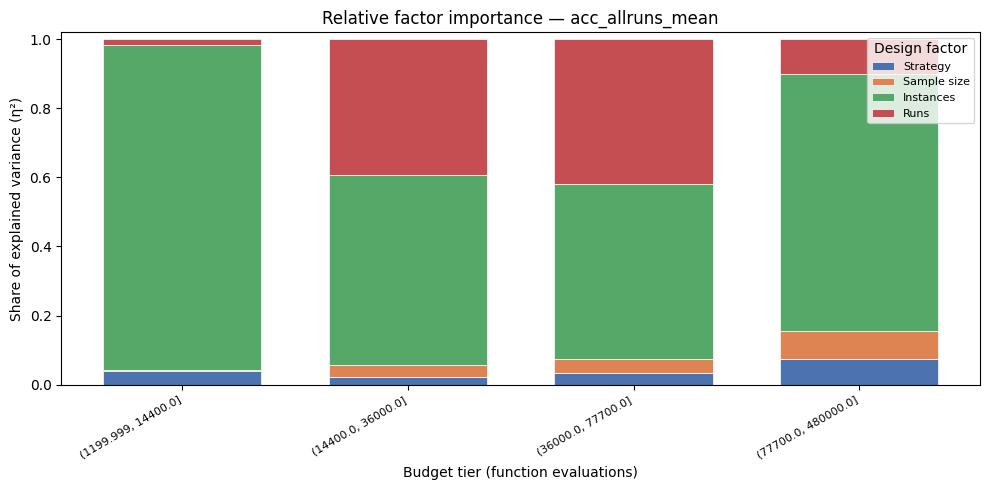

In [28]:
imp_df_excl_cma = run_all(fold_agg_df, metric="acc_allruns_mean", omit_strategies={"cma_random"})

In [29]:
fold_agg_df["budget_level"] = pd.qcut(
    fold_agg_df["n_feval_train"],
    q=12,
)

fold_agg_df.groupby("budget_level").agg(
    max_acc=("acc_allruns_mean", "max"),
)

,max_acc
budget_level,
"(1199.999, 4800.0]",0.720444
"(4800.0, 9600.0]",0.819535
"(9600.0, 14400.0]",0.826601
"(14400.0, 18000.0]",0.857719
"(18000.0, 24000.0]",0.864632
"(24000.0, 36000.0]",0.880205
"(36000.0, 48000.0]",0.886194
"(48000.0, 60000.0]",0.889788
"(60000.0, 77700.0]",0.897174


### Correlation between CV and accuracy
Plot 3: does the accuracy gap between high-CV and low-CV configurations shrink or grow as you add more instances/runs?

In [30]:
from rq2_cv_accuracy import *

Pair-level data (20 strategy×size combos):
sampling_strategy  sample_size_per_dim       cv  acc_mean  acc_std  n_configs
       cma_random                   25 0.490284  0.573456 0.118159         32
       cma_random                   50 0.467463  0.636491 0.123187         32
       cma_random                   75 0.490092  0.651089 0.120000         32
       cma_random                  100 0.526402  0.655436 0.114895         32
             ilhs                   25 0.211366  0.780226 0.114458         32
             ilhs                   50 0.174404  0.814809 0.095526         32
             ilhs                   75 0.116454  0.827866 0.087939         32
             ilhs                  100 0.103149  0.837178 0.084479         32
              lhs                   25 0.291499  0.753660 0.118034         32
              lhs                   50 0.237537  0.795251 0.105043         32
              lhs                   75 0.147355  0.813873 0.098100         32
              lhs    

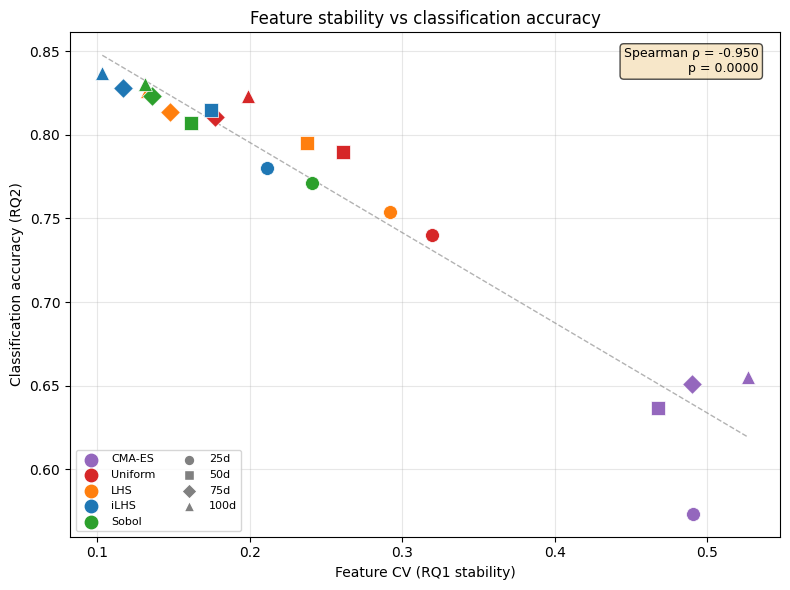

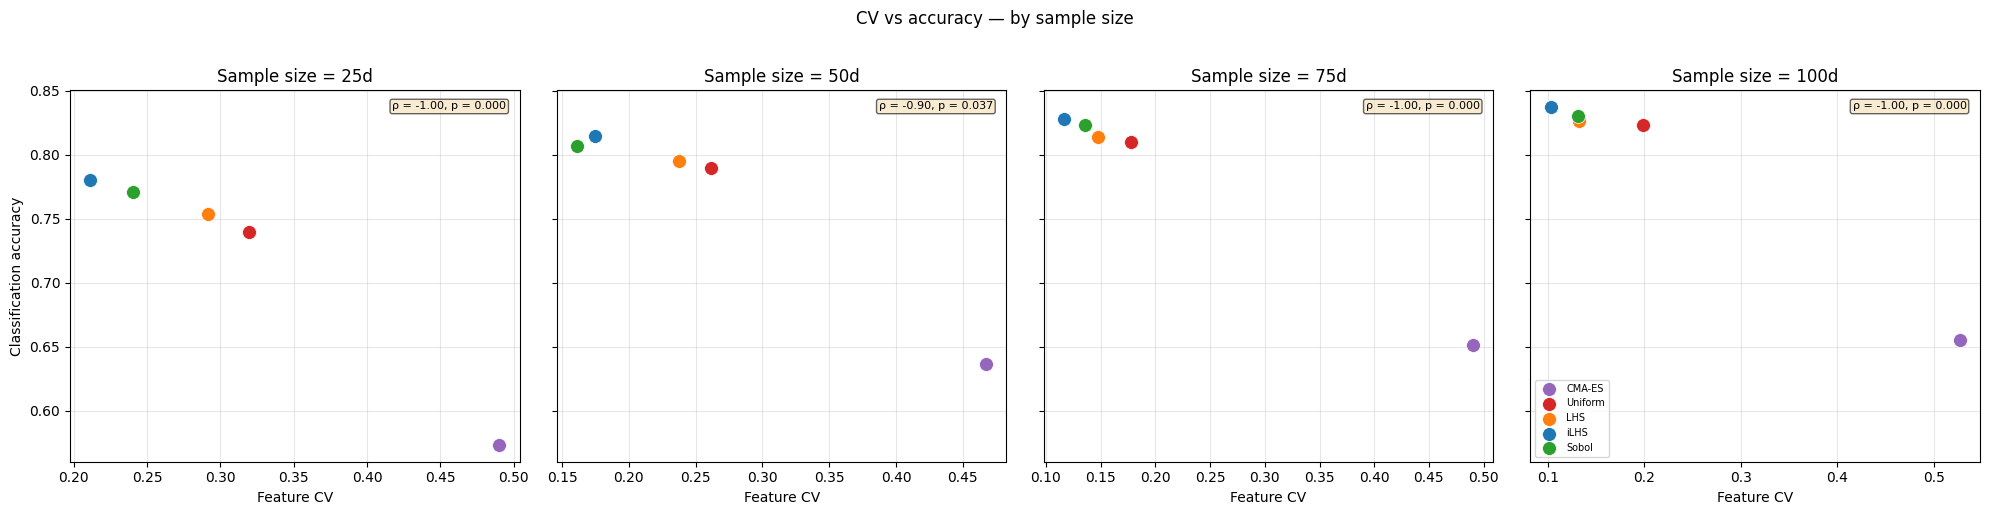

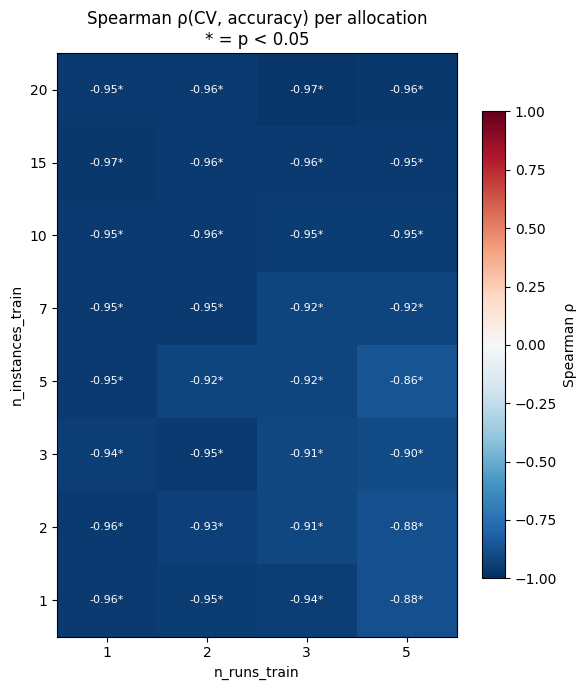


Partial correlation analysis:
        analysis     controlling_for   n  spearman_rho      p_value
             Raw                   — 640     -0.537051 4.229197e-49
         Partial sample_size_per_dim 640     -0.447626 7.372586e-33
         Partial       n_feval_train 640     -0.501913 3.861659e-42
 Within size=25d        (stratified) 160     -0.486271 7.085865e-11
 Within size=50d        (stratified) 160     -0.429626 1.434695e-08
 Within size=75d        (stratified) 160     -0.437951 6.977251e-09
Within size=100d        (stratified) 160     -0.438190 6.832040e-09



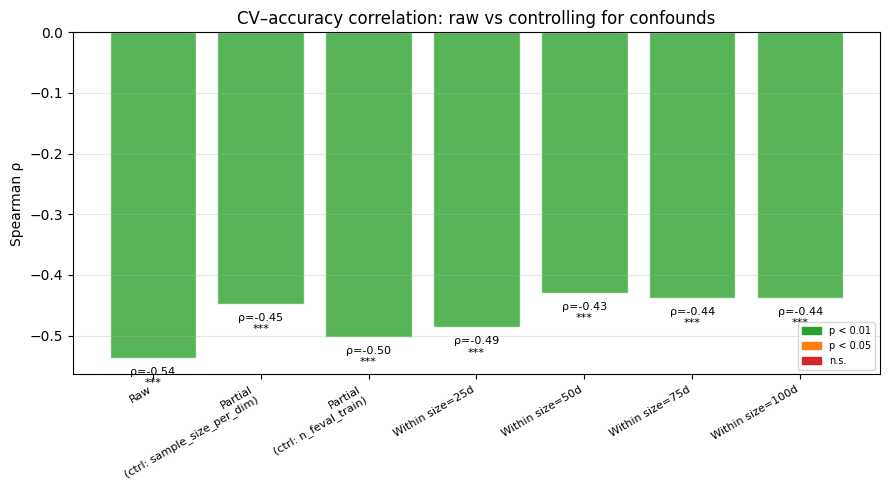

Full correlation summary:
      level level_value   n  spearman_rho      p_value
     global         all 640     -0.537051 4.229197e-49
sample_size          25 160     -0.486271 7.085865e-11
sample_size          50 160     -0.429626 1.434695e-08
sample_size          75 160     -0.437951 6.977251e-09
sample_size         100 160     -0.438190 6.832040e-09
 allocation  1inst_1run  20     -0.959398 2.456976e-11
 allocation  1inst_2run  20     -0.948872 1.882170e-10
 allocation  1inst_3run  20     -0.938346 9.762241e-10
 allocation  1inst_5run  20     -0.882707 2.588147e-07
 allocation  2inst_1run  20     -0.960902 1.759049e-11
 allocation  2inst_2run  20     -0.932331 2.206697e-09
 allocation  2inst_3run  20     -0.911278 2.336013e-08
 allocation  2inst_5run  20     -0.882707 2.588147e-07
 allocation  3inst_1run  20     -0.944361 3.962327e-10
 allocation  3inst_2run  20     -0.953383 8.333046e-11
 allocation  3inst_3run  20     -0.908271 3.118101e-08
 allocation  3inst_5run  20     -0.8977

(          level  level_value    n  spearman_rho       p_value
 0        global          all  640     -0.537051  4.229197e-49
 1   sample_size           25  160     -0.486271  7.085865e-11
 2   sample_size           50  160     -0.429626  1.434695e-08
 3   sample_size           75  160     -0.437951  6.977251e-09
 4   sample_size          100  160     -0.438190  6.832040e-09
 5    allocation   1inst_1run   20     -0.959398  2.456976e-11
 6    allocation   1inst_2run   20     -0.948872  1.882170e-10
 7    allocation   1inst_3run   20     -0.938346  9.762241e-10
 8    allocation   1inst_5run   20     -0.882707  2.588147e-07
 9    allocation   2inst_1run   20     -0.960902  1.759049e-11
 10   allocation   2inst_2run   20     -0.932331  2.206697e-09
 11   allocation   2inst_3run   20     -0.911278  2.336013e-08
 12   allocation   2inst_5run   20     -0.882707  2.588147e-07
 13   allocation   3inst_1run   20     -0.944361  3.962327e-10
 14   allocation   3inst_2run   20     -0.953383  8.333

In [31]:
run_all(fold_agg_df, cv_col="cv_instance_median_mean",
                               acc_col="acc_allruns_mean")


Pair-level data (20 strategy×size combos):
sampling_strategy  sample_size_per_dim       cv  acc_mean  acc_std  n_configs
       cma_random                   25 0.828863  0.573456 0.118159         32
       cma_random                   50 0.795914  0.636491 0.123187         32
       cma_random                   75 0.800398  0.651089 0.120000         32
       cma_random                  100 0.903144  0.655436 0.114895         32
             ilhs                   25 0.652068  0.780226 0.114458         32
             ilhs                   50 0.578636  0.814809 0.095526         32
             ilhs                   75 0.528328  0.827866 0.087939         32
             ilhs                  100 0.551289  0.837178 0.084479         32
              lhs                   25 0.718700  0.753660 0.118034         32
              lhs                   50 0.609661  0.795251 0.105043         32
              lhs                   75 0.557796  0.813873 0.098100         32
              lhs    

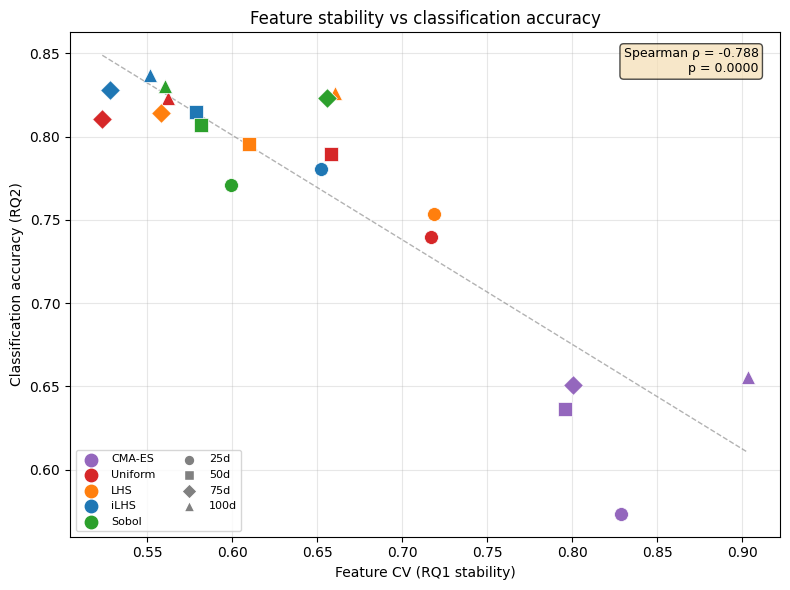

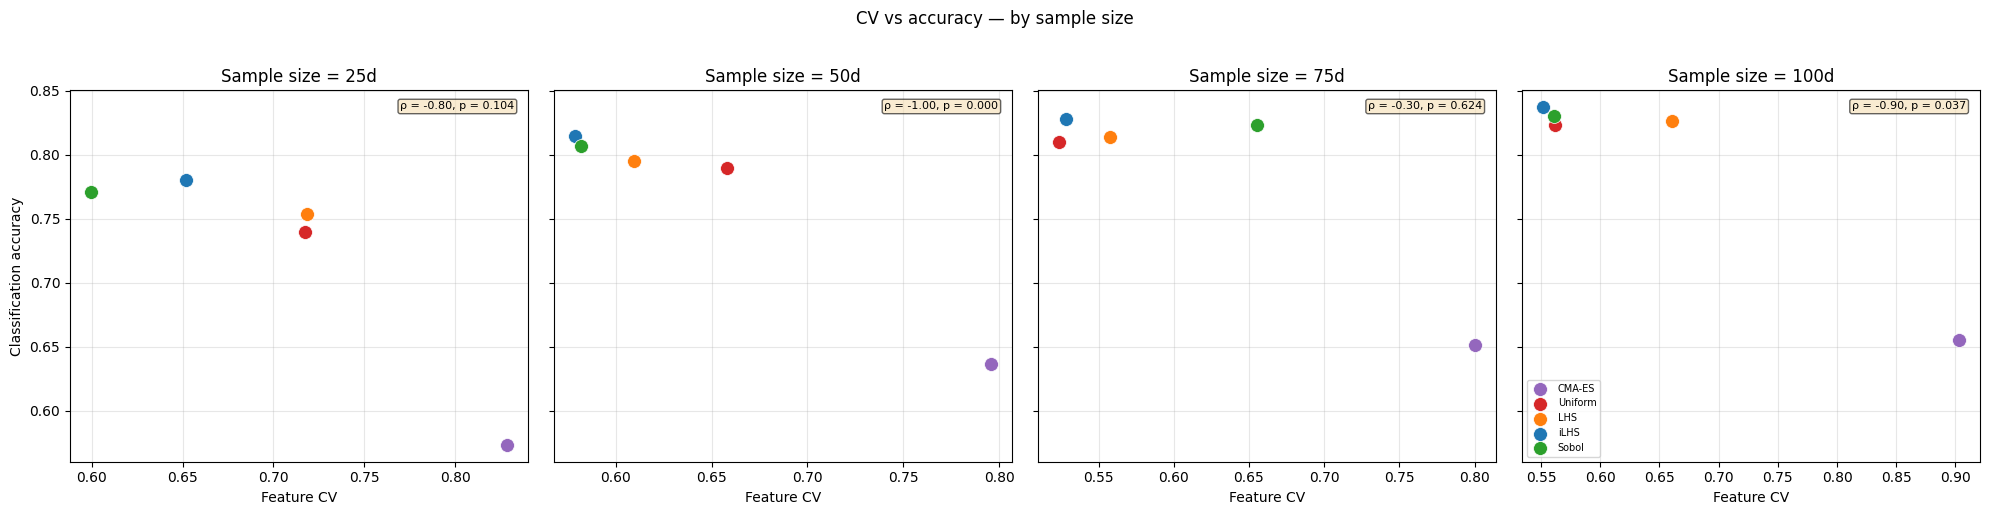

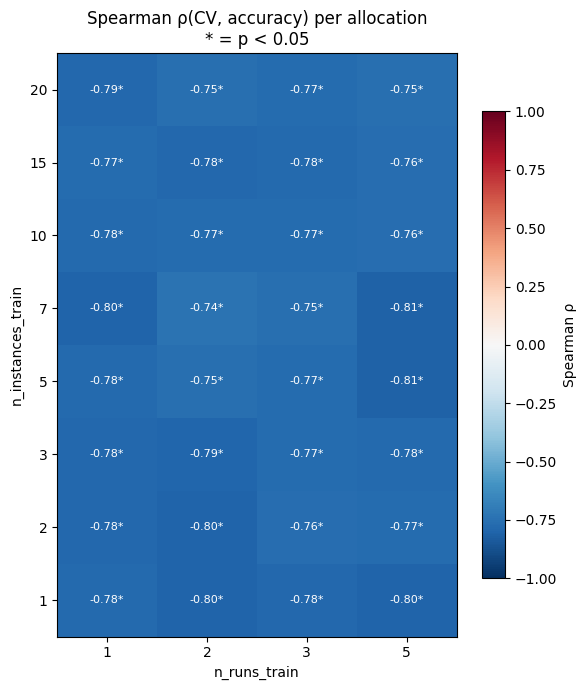


Partial correlation analysis:
        analysis     controlling_for   n  spearman_rho      p_value
             Raw                   — 640     -0.488906 9.212996e-40
         Partial sample_size_per_dim 640     -0.400920 4.133804e-26
         Partial       n_feval_train 640     -0.486861 2.133083e-39
 Within size=25d        (stratified) 160     -0.448476 2.726353e-09
 Within size=50d        (stratified) 160     -0.443692 4.195701e-09
 Within size=75d        (stratified) 160     -0.359872 2.955004e-06
Within size=100d        (stratified) 160     -0.432066 1.163743e-08



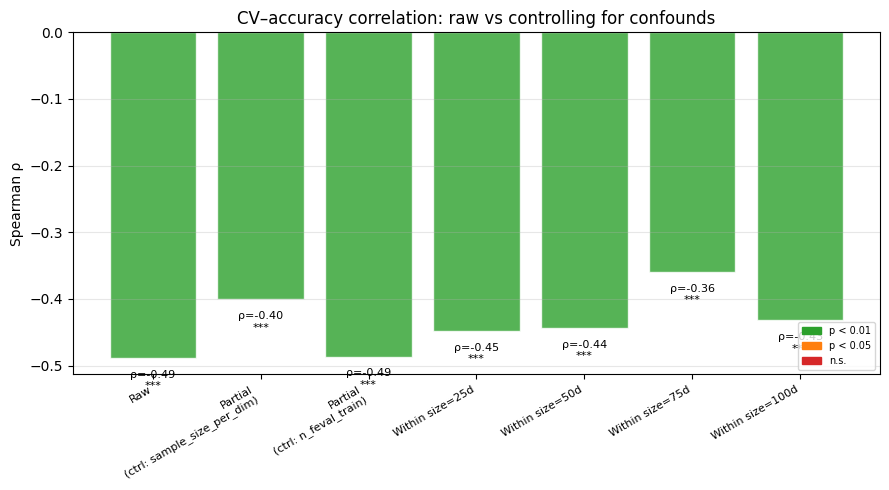

Full correlation summary:
      level level_value   n  spearman_rho      p_value
     global         all 640     -0.488906 9.212996e-40
sample_size          25 160     -0.448476 2.726353e-09
sample_size          50 160     -0.443692 4.195701e-09
sample_size          75 160     -0.359872 2.955004e-06
sample_size         100 160     -0.432066 1.163743e-08
 allocation  1inst_1run  20     -0.777444 5.488285e-05
 allocation  1inst_2run  20     -0.798496 2.438358e-05
 allocation  1inst_3run  20     -0.781955 4.646776e-05
 allocation  1inst_5run  20     -0.800000 2.292887e-05
 allocation  2inst_1run  20     -0.783459 4.392227e-05
 allocation  2inst_2run  20     -0.796992 2.591747e-05
 allocation  2inst_3run  20     -0.759398 1.030315e-04
 allocation  2inst_5run  20     -0.768421 7.571881e-05
 allocation  3inst_1run  20     -0.781955 4.646776e-05
 allocation  3inst_2run  20     -0.790977 3.291873e-05
 allocation  3inst_3run  20     -0.772932 6.458024e-05
 allocation  3inst_5run  20     -0.7774

(          level  level_value    n  spearman_rho       p_value
 0        global          all  640     -0.488906  9.212996e-40
 1   sample_size           25  160     -0.448476  2.726353e-09
 2   sample_size           50  160     -0.443692  4.195701e-09
 3   sample_size           75  160     -0.359872  2.955004e-06
 4   sample_size          100  160     -0.432066  1.163743e-08
 5    allocation   1inst_1run   20     -0.777444  5.488285e-05
 6    allocation   1inst_2run   20     -0.798496  2.438358e-05
 7    allocation   1inst_3run   20     -0.781955  4.646776e-05
 8    allocation   1inst_5run   20     -0.800000  2.292887e-05
 9    allocation   2inst_1run   20     -0.783459  4.392227e-05
 10   allocation   2inst_2run   20     -0.796992  2.591747e-05
 11   allocation   2inst_3run   20     -0.759398  1.030315e-04
 12   allocation   2inst_5run   20     -0.768421  7.571881e-05
 13   allocation   3inst_1run   20     -0.781955  4.646776e-05
 14   allocation   3inst_2run   20     -0.790977  3.291

In [32]:
run_all(fold_agg_df, cv_col="cv_function_median_mean", acc_col="acc_allruns_mean")


Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Pair-level data (16 strategy×size combos):
sampling_strategy  sample_size_per_dim       cv  acc_mean  acc_std  n_configs
             ilhs                   25 0.211366  0.780226 0.114458         32
             ilhs                   50 0.174404  0.814809 0.095526         32
             ilhs                   75 0.116454  0.827866 0.087939         32
             ilhs                  100 0.103149  0.837178 0.084479         32
              lhs                   25 0.291499  0.753660 0.118034         32
              lhs                   50 0.237537  0.795251 0.105043         32
              lhs                   75 0.147355  0.813873 0.098100         32
              lhs                  100 0.132414  0.826162 0.093003         32
            sobol                   25 0.240613  0.770974 0.114371         32
            sobol                   50 0.161319  0.807018 0.100113         32
            sobol   

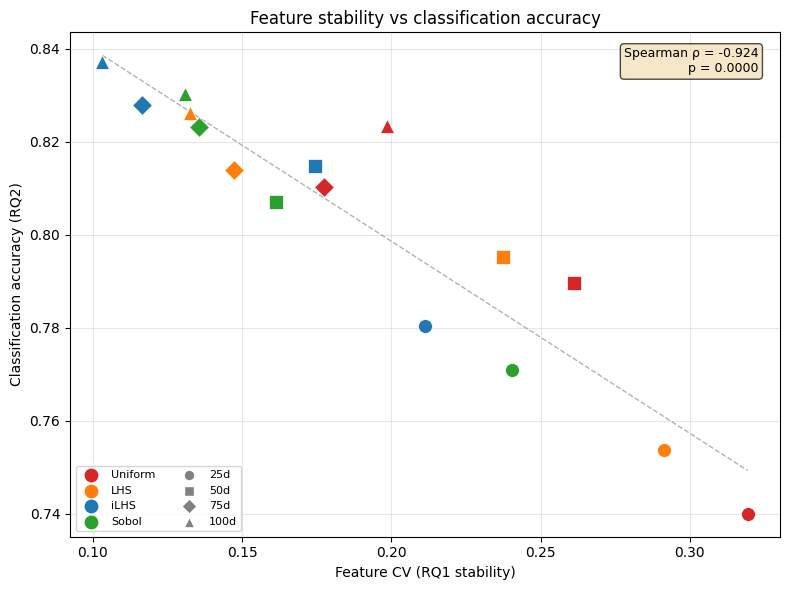

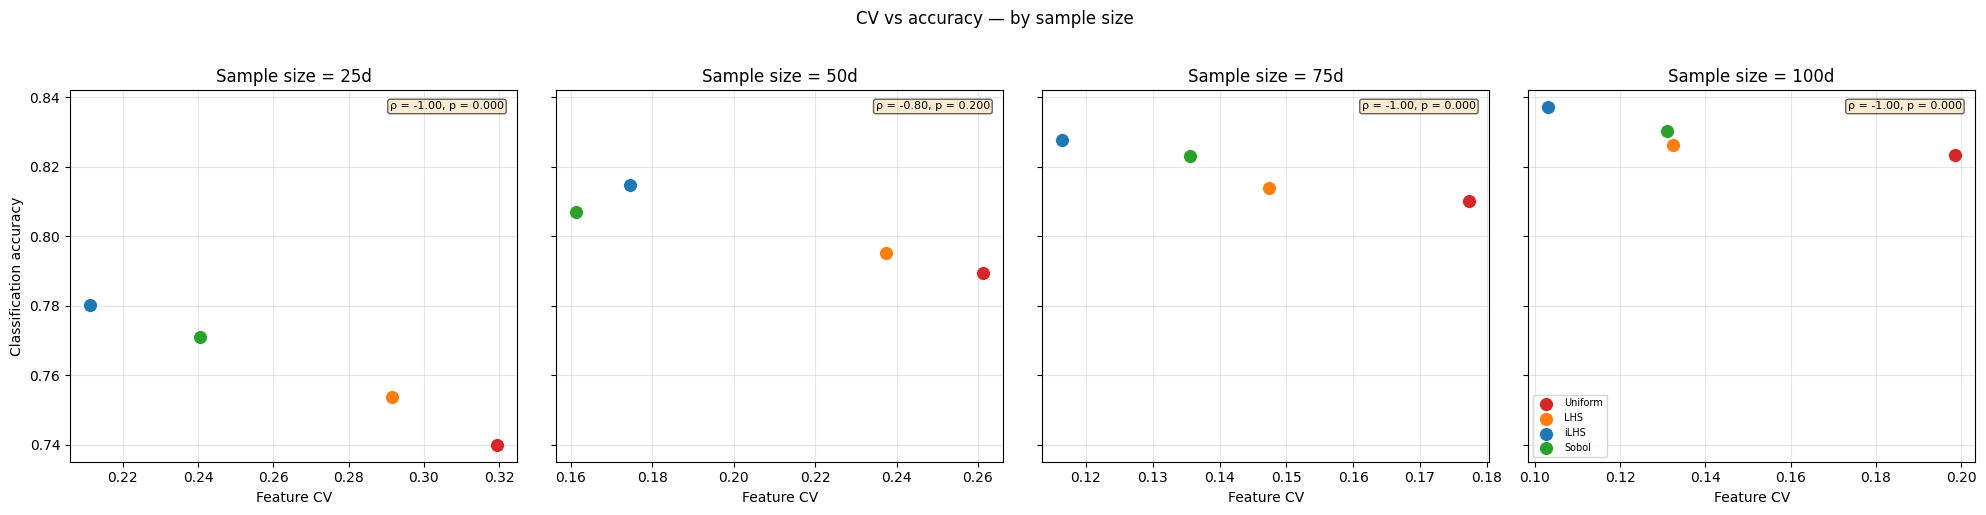

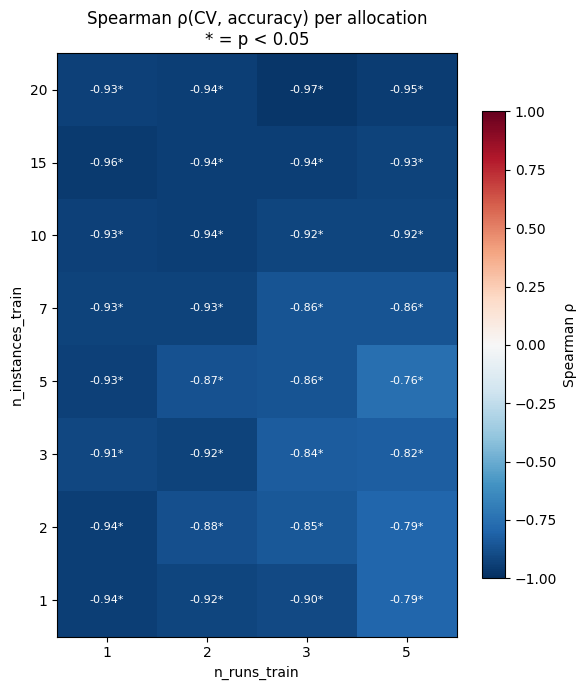


Partial correlation analysis:
        analysis     controlling_for   n  spearman_rho      p_value
             Raw                   — 512     -0.301762 3.066492e-12
         Partial sample_size_per_dim 512     -0.122709 5.430578e-03
         Partial       n_feval_train 512     -0.044712 3.126191e-01
 Within size=25d        (stratified) 128     -0.200841 2.301496e-02
 Within size=50d        (stratified) 128     -0.112524 2.060155e-01
 Within size=75d        (stratified) 128     -0.103068 2.469731e-01
Within size=100d        (stratified) 128     -0.082928 3.520505e-01



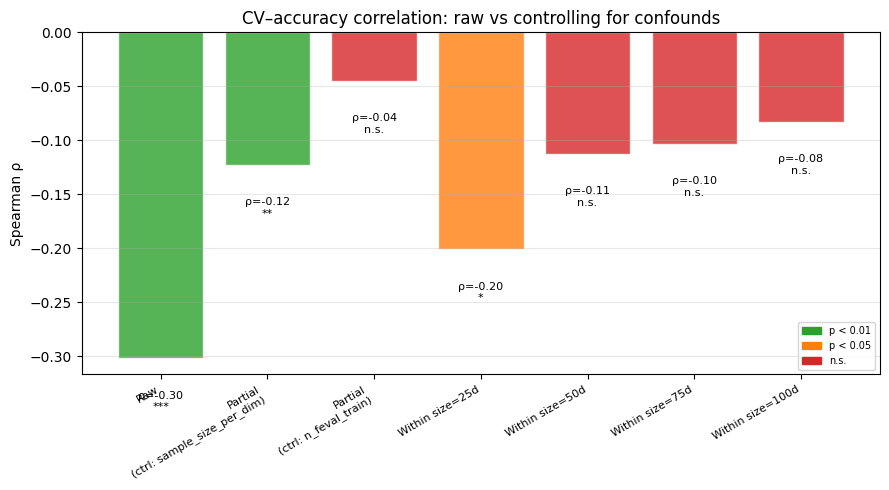

Full correlation summary:
      level level_value   n  spearman_rho      p_value
     global         all 512     -0.301762 3.066492e-12
sample_size          25 128     -0.200841 2.301496e-02
sample_size          50 128     -0.112524 2.060155e-01
sample_size          75 128     -0.103068 2.469731e-01
sample_size         100 128     -0.082928 3.520505e-01
 allocation  1inst_1run  16     -0.941176 5.588938e-08
 allocation  1inst_2run  16     -0.920588 4.320410e-07
 allocation  1inst_3run  16     -0.900000 2.051090e-06
 allocation  1inst_5run  16     -0.791176 2.619464e-04
 allocation  2inst_1run  16     -0.944118 3.933929e-08
 allocation  2inst_2run  16     -0.882353 6.095620e-06
 allocation  2inst_3run  16     -0.847059 3.468046e-05
 allocation  2inst_5run  16     -0.791176 2.619464e-04
 allocation  3inst_1run  16     -0.911765 8.818986e-07
 allocation  3inst_2run  16     -0.923529 3.343900e-07
 allocation  3inst_3run  16     -0.835294 5.637132e-05
 allocation  3inst_5run  16     -0.8205

In [33]:
corr_df = run_all(fold_agg_df, cv_col="cv_instance_median_mean", acc_col="acc_allruns_mean", omit_strategies="cma_random")



  Type II ANOVA — Main Effects
                SS       df        F  p-value     η²
Strategy    3.1307   4.0000 929.8663   0.0000 0.2988
Sample size 0.4743   3.0000 187.8429   0.0000 0.0453
Instances   5.8078   7.0000 985.7301   0.0000 0.5544
Runs        0.5395   3.0000 213.6437   0.0000 0.0515
Residual    0.5235 622.0000      NaN      NaN 0.0500

  → Dominant factor: Instances (η² = 0.554)



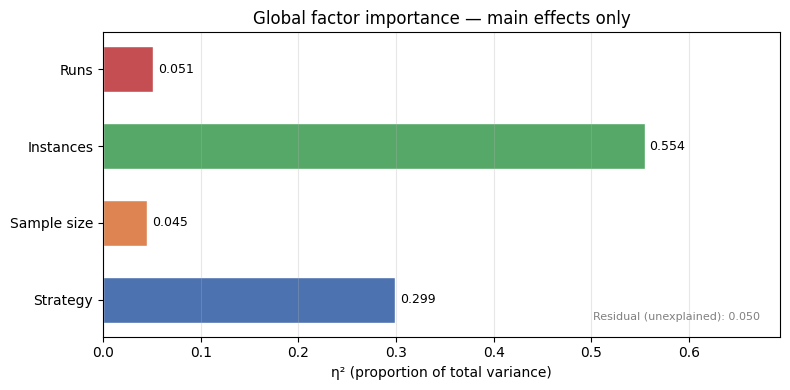


  Type II ANOVA — Main Effects + Two-Way Interactions
                            SS       df         F  p-value     η²
Strategy                3.1307   4.0000 9188.4225   0.0000 0.2988
Sample size             0.4743   3.0000 1856.1595   0.0000 0.0453
Instances               5.8078   7.0000 9740.4373   0.0000 0.5544
Runs                    0.5395   3.0000 2111.1085   0.0000 0.0515
Strategy × Sample size  0.0162  12.0000   15.8313   0.0000 0.0015
Strategy × Instances    0.0283  28.0000   11.8798   0.0000 0.0027
Strategy × Runs         0.1303  12.0000  127.4365   0.0000 0.0124
Sample size × Instances 0.0333  21.0000   18.5946   0.0000 0.0032
Sample size × Runs      0.0166   9.0000   21.6956   0.0000 0.0016
Instances × Runs        0.2547  21.0000  142.3649   0.0000 0.0243
Residual                0.0442 519.0000       NaN      NaN 0.0042

  → Dominant factor: Instances (η² = 0.554)



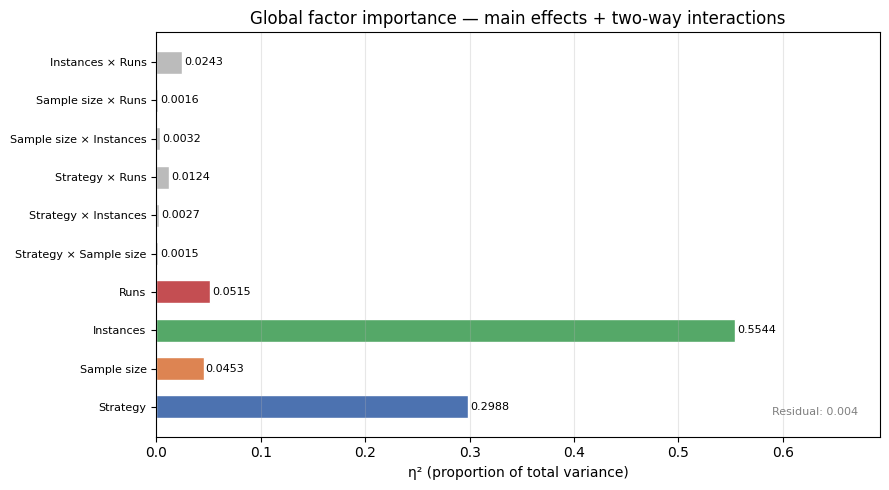


Pairwise interaction η²:
   factor_a    factor_b  eta_sq_a  eta_sq_b  eta_sq_joint  eta_sq_interaction
   Strategy Sample size  0.298847  0.045278      0.345670            0.001545
   Strategy   Instances  0.298847  0.554402      0.855954            0.002705
   Strategy        Runs  0.298847  0.051497      0.362779            0.012434
Sample size   Instances  0.045278  0.554402      0.602855            0.003175
Sample size        Runs  0.045278  0.051497      0.098362            0.001588
  Instances        Runs  0.554402  0.051497      0.630208            0.024309



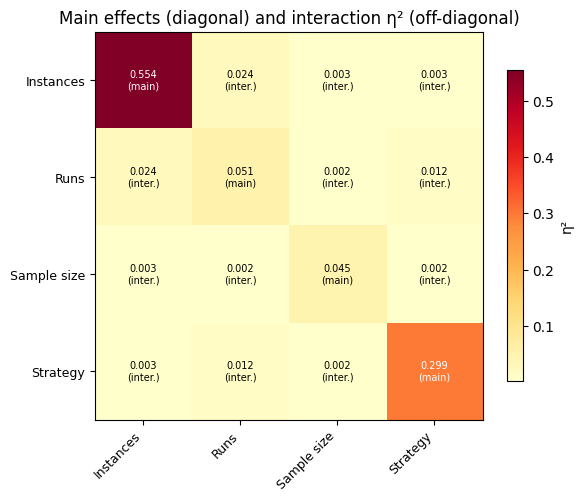

In [34]:
from rq2_global_anova import *

# Full analysis
anova_df, interaction_df = run_all(fold_agg_df, metric="acc_allruns_mean")



Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']


  Type II ANOVA — Main Effects
                SS       df         F  p-value     η²
Strategy    0.0058   3.0000    4.4409   0.0043 0.0013
Sample size 0.1399   3.0000  107.2714   0.0000 0.0318
Instances   3.9150   7.0000 1286.9810   0.0000 0.8900
Runs        0.1232   3.0000   94.5330   0.0000 0.0280
Residual    0.2151 495.0000       NaN      NaN 0.0489

  → Dominant factor: Instances (η² = 0.890)



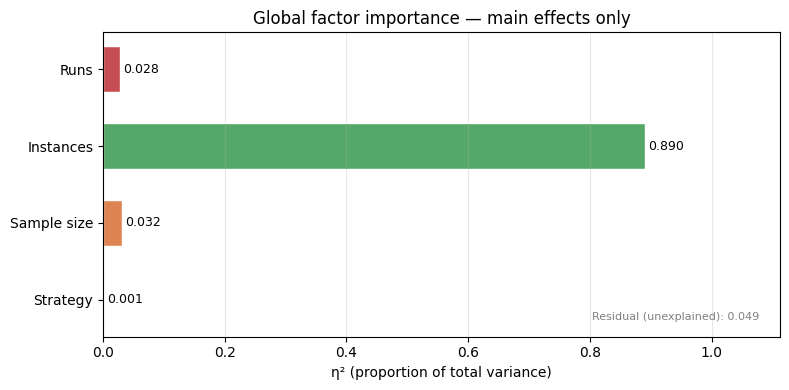


  Type II ANOVA — Main Effects + Two-Way Interactions
                            SS       df         F  p-value     η²
Strategy                0.0058   3.0000   32.3973   0.0000 0.0013
Sample size             0.1399   3.0000  782.5680   0.0000 0.0318
Instances               3.9150   7.0000 9388.8038   0.0000 0.8900
Runs                    0.1232   3.0000  689.6385   0.0000 0.0280
Strategy × Sample size  0.0046   9.0000    8.5891   0.0000 0.0010
Strategy × Instances    0.0032  21.0000    2.5917   0.0002 0.0007
Strategy × Runs         0.0074   9.0000   13.7153   0.0000 0.0017
Sample size × Instances 0.0283  21.0000   22.6141   0.0000 0.0064
Sample size × Runs      0.0089   9.0000   16.5381   0.0000 0.0020
Instances × Runs        0.1386  21.0000  110.8203   0.0000 0.0315
Residual                0.0241 405.0000       NaN      NaN 0.0055

  → Dominant factor: Instances (η² = 0.890)



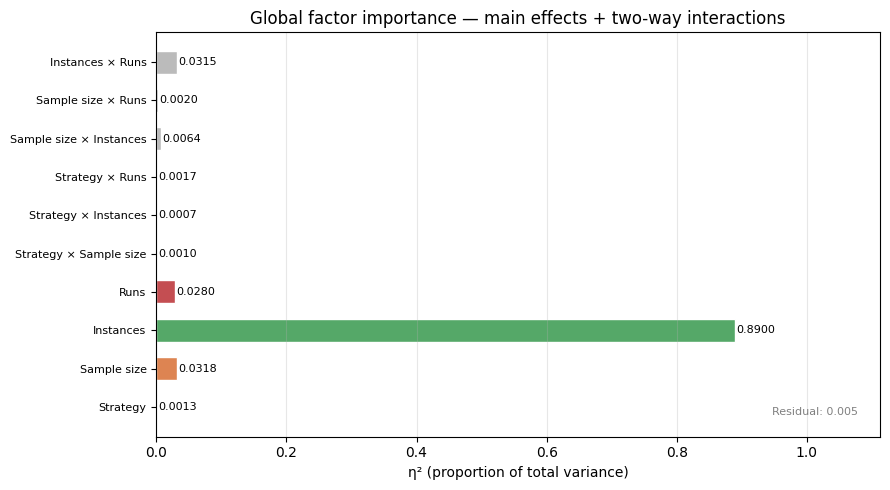


Pairwise interaction η²:
   factor_a    factor_b  eta_sq_a  eta_sq_b  eta_sq_joint  eta_sq_interaction
   Strategy Sample size  0.001316  0.031792      0.034155            0.001047
   Strategy   Instances  0.001316  0.889975      0.892028            0.000737
   Strategy        Runs  0.001316  0.028016      0.031004            0.001672
Sample size   Instances  0.031792  0.889975      0.928198            0.006431
Sample size        Runs  0.031792  0.028016      0.061824            0.002016
  Instances        Runs  0.889975  0.028016      0.949506            0.031514



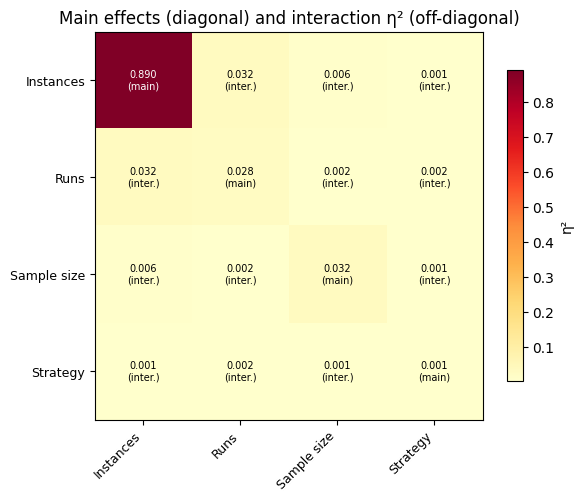

In [35]:
# Without CMA-ES
anova_df, interaction_df = run_all(fold_agg_df, metric="acc_mean",
                                    omit_strategies="cma_random")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']


Factor            η² (raw)   η² (adj)     Change
--------------------------------------------------
Strategy            0.0082     0.0012     -85.4%
Sample size         0.0626     0.0042     -93.2%
Instances           0.8272     0.0164     -98.0%
Runs                0.0478     0.0098     -79.6%
log(budget)              —     0.9605
Residual (Raw)      0.0542
Residual (Adjusted)     0.0079

Plot 1: Raw vs budget-adjusted η² ...


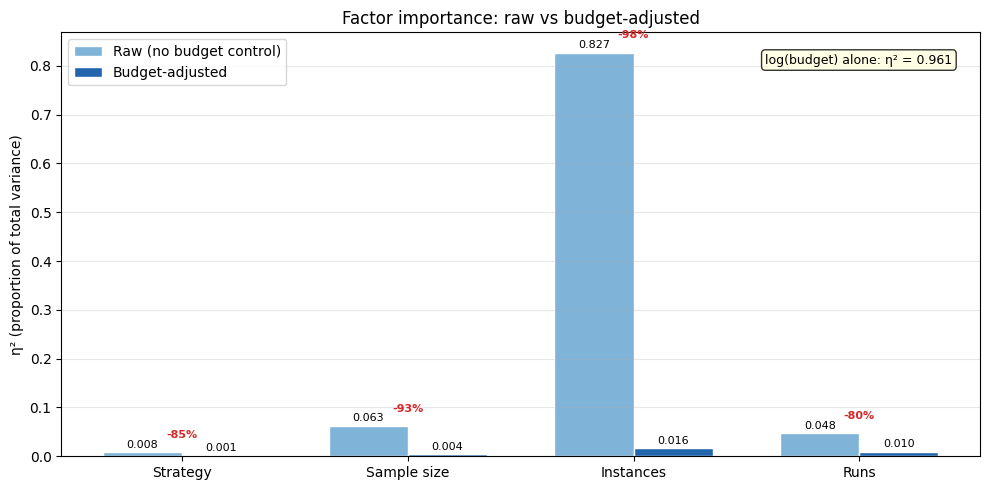

Plot 2: Partial regression (added-variable) plots ...


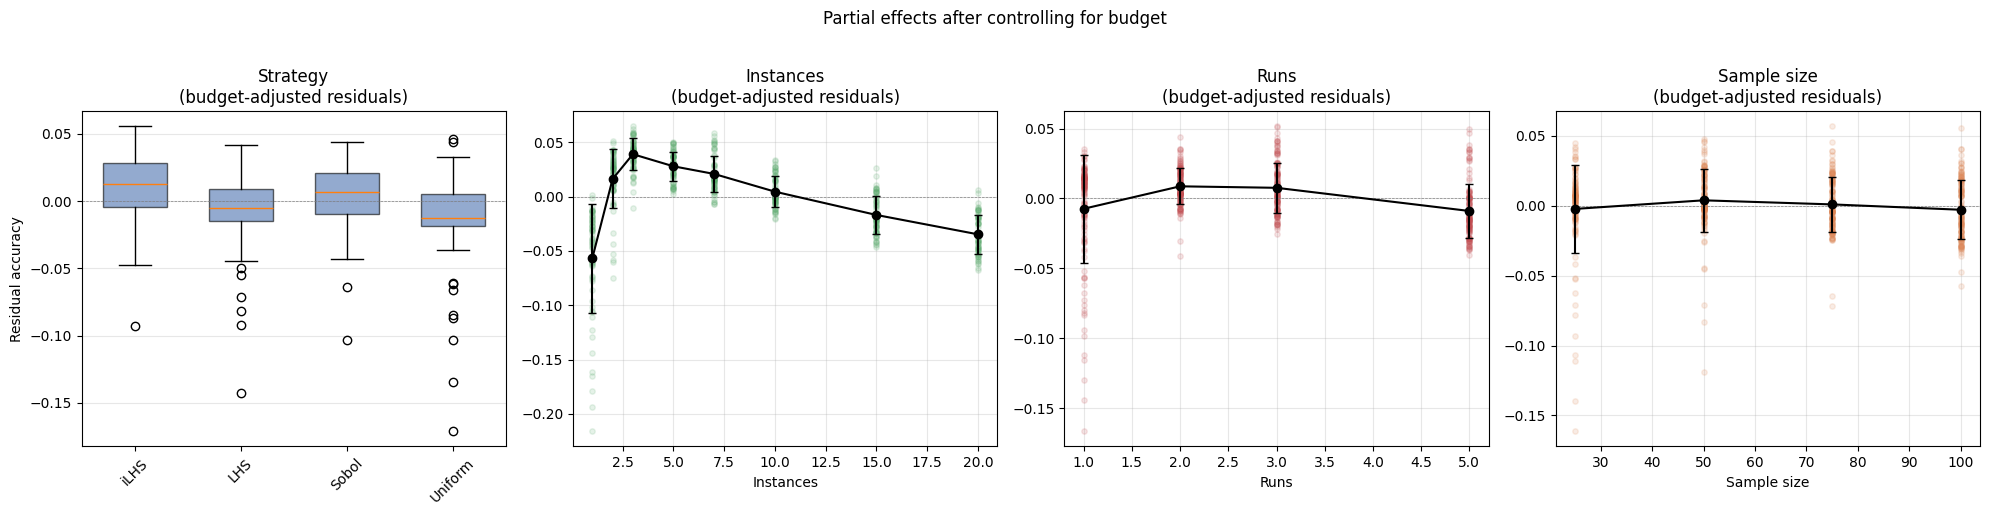

Plot 3: Raw vs adjusted marginal means ...


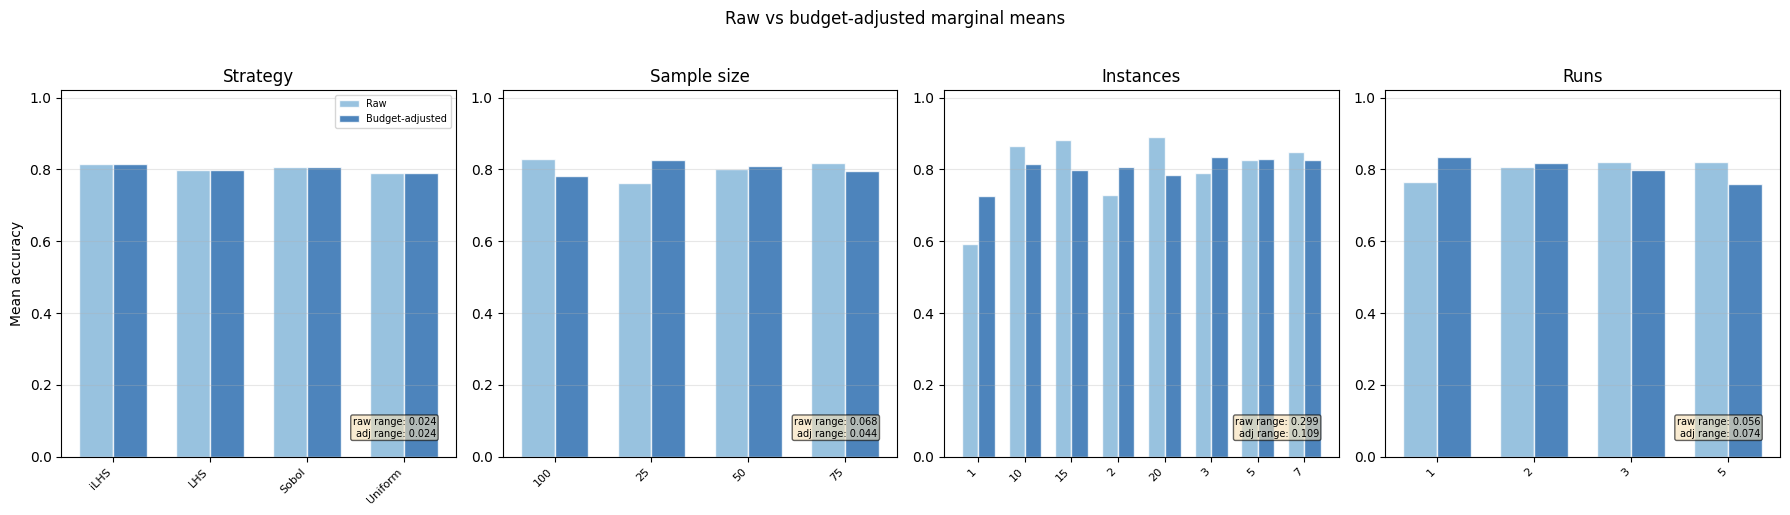

In [36]:
from rq2_budget_adjusted import *

results = run_all(fold_agg_df, metric="acc_allruns_mean", omit_strategies="cma_random")

Fitting random forest ...
Random forest R² = 0.9439
Factors: ['sampling_strategy', 'sample_size_per_dim', 'n_instances_train', 'n_runs_train']

Computing fANOVA decomposition ...

Main effects:
             factor factor_label  importance  importance_pct
  sampling_strategy     Strategy    0.004635       31.714147
sample_size_per_dim  Sample size    0.000227        1.550928
  n_instances_train    Instances    0.008512       58.237417
       n_runs_train         Runs    0.000649        4.437088

Interactions:
           factor_a            factor_b                   label  importance  importance_pct
  sampling_strategy sample_size_per_dim  Strategy × Sample size    0.000027        0.182242
  sampling_strategy   n_instances_train    Strategy × Instances    0.000066        0.449162
  sampling_strategy        n_runs_train         Strategy × Runs    0.000082        0.562671
sample_size_per_dim   n_instances_train Sample size × Instances    0.000015        0.102924
sample_size_per_dim       

/Users/leekaijen/Documents/MSCS/thesis/MSc-Thesis-Problem-Embedding-Transfer-Learning/venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


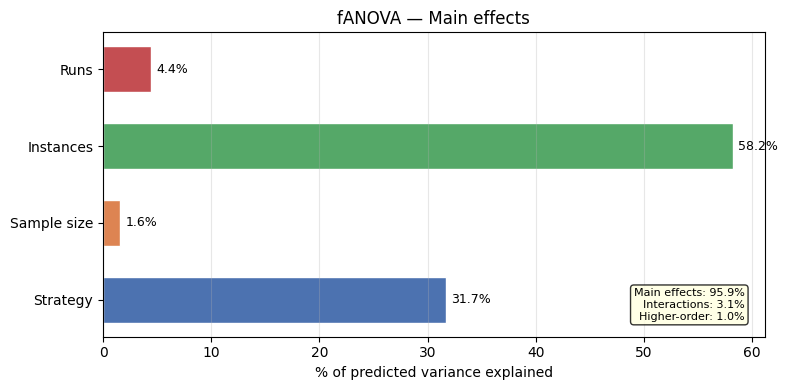

Plot 2: Main effects + interactions ...


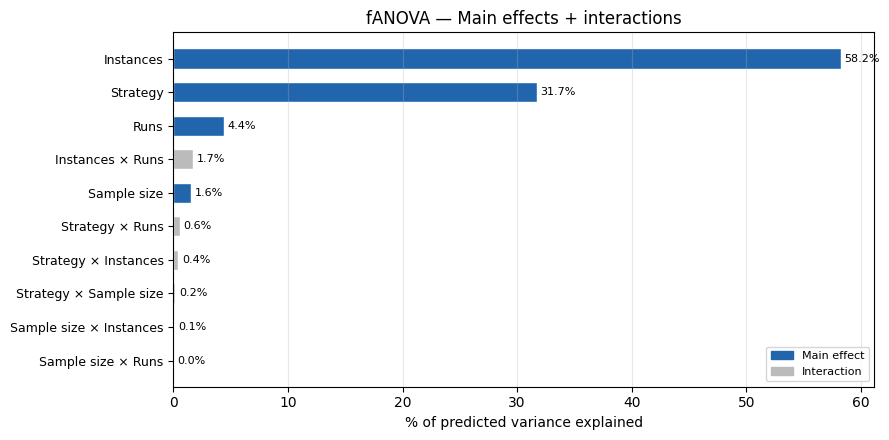

Plot 3: Marginal effect curves ...


/Users/leekaijen/Documents/MSCS/thesis/MSc-Thesis-Problem-Embedding-Transfer-Learning/venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


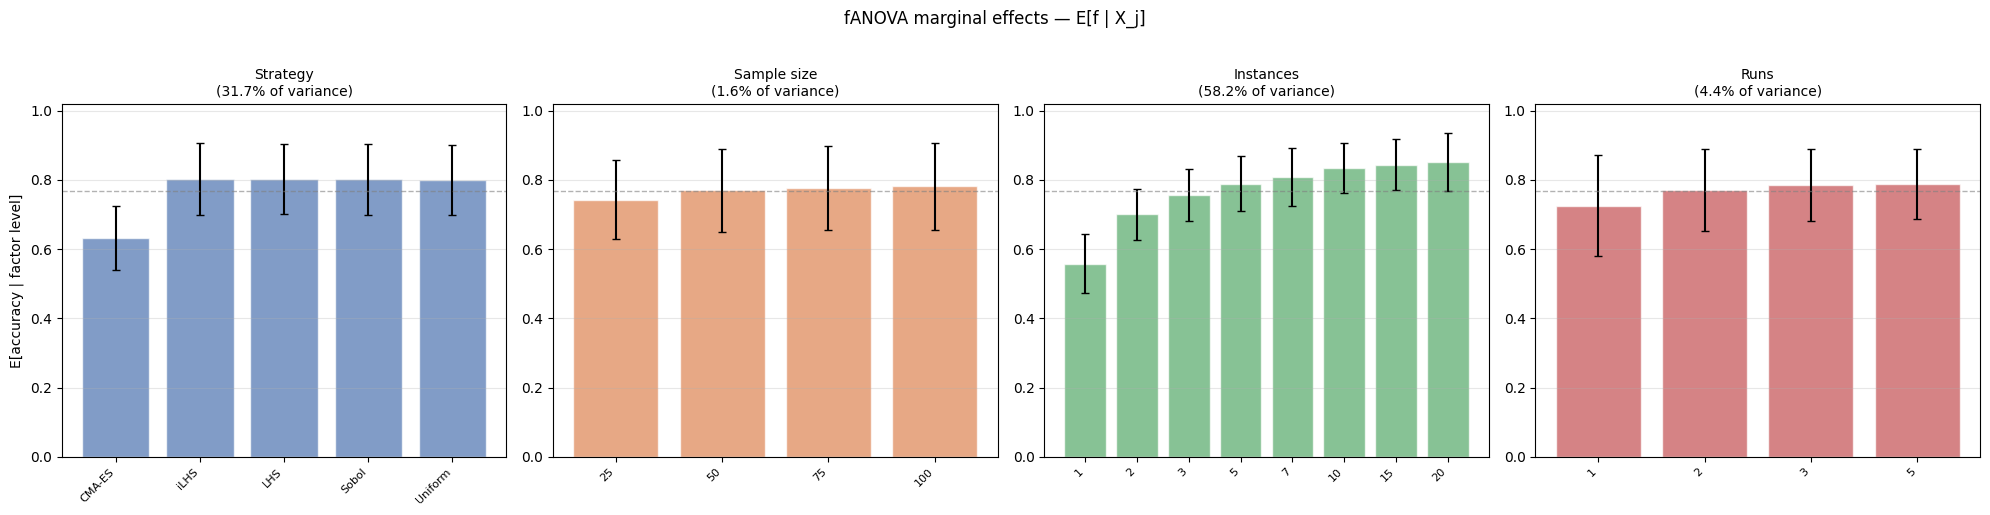

Plot 4: Interaction heatmap ...


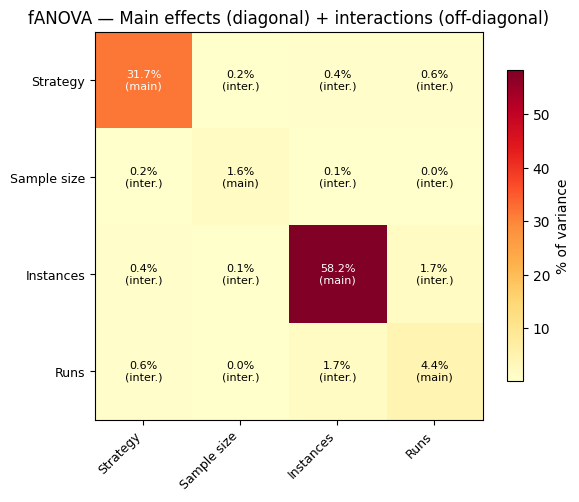

In [37]:
from rq2_fanova import *

result = run_all(fold_agg_df, metric="acc_allruns_mean")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Fitting random forest ...
Random forest R² = 0.9565
Factors: ['sampling_strategy', 'sample_size_per_dim', 'n_instances_train', 'n_runs_train']

Computing fANOVA decomposition ...

Main effects:
             factor factor_label  importance  importance_pct
  sampling_strategy     Strategy    0.000002        0.018995
sample_size_per_dim  Sample size    0.000302        3.006689
  n_instances_train    Instances    0.008877       88.402563
       n_runs_train         Runs    0.000415        4.135990

Interactions:
           factor_a            factor_b                   label   importance  importance_pct
  sampling_strategy sample_size_per_dim  Strategy × Sample size 1.483848e-07        0.001478
  sampling_strategy   n_instances_train    Strategy × Instances 2.621834e-07        0.002611
  sampling_strategy        n_runs_train         Strategy × Runs 1.646508e-07        0.001640
sample_size_per_dim   n_instances_t

/Users/leekaijen/Documents/MSCS/thesis/MSc-Thesis-Problem-Embedding-Transfer-Learning/venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


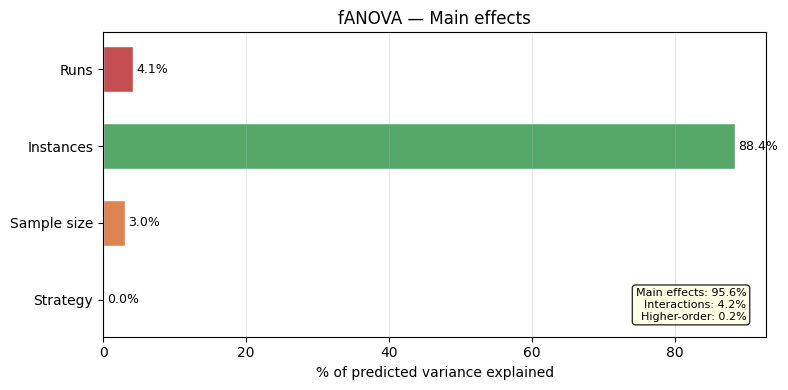

Plot 2: Main effects + interactions ...


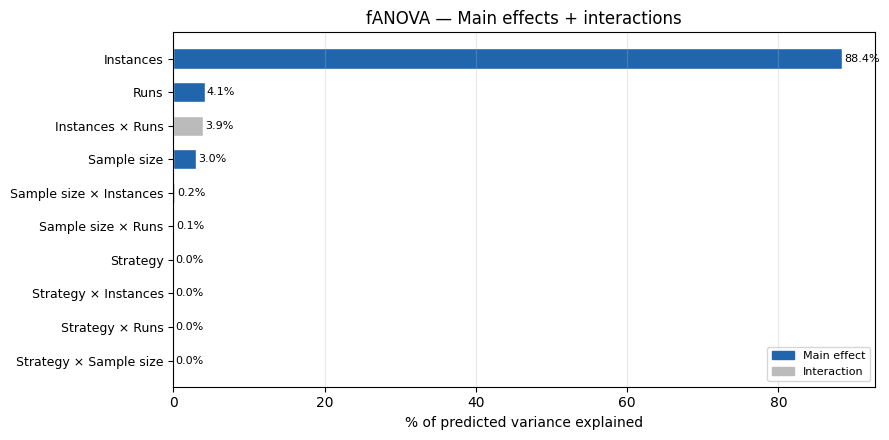

Plot 3: Marginal effect curves ...


/Users/leekaijen/Documents/MSCS/thesis/MSc-Thesis-Problem-Embedding-Transfer-Learning/venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


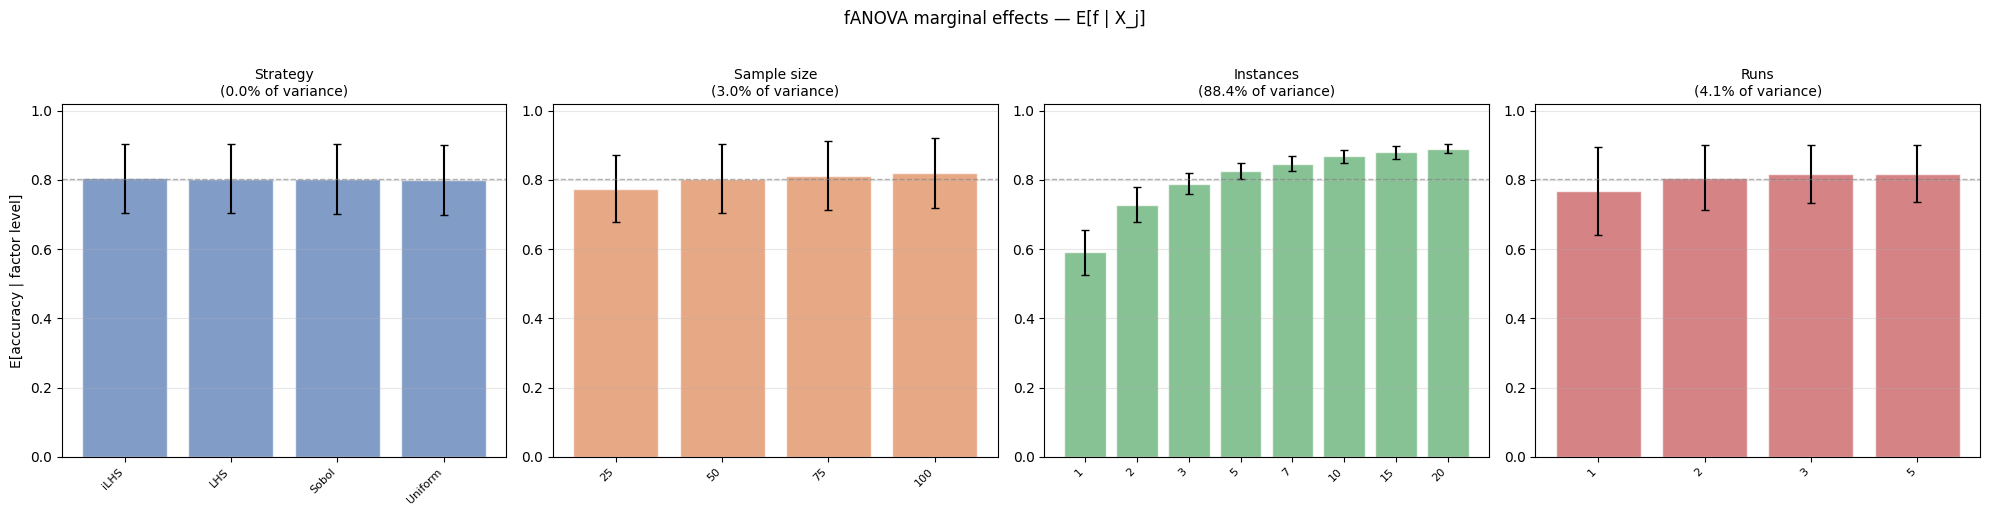

Plot 4: Interaction heatmap ...


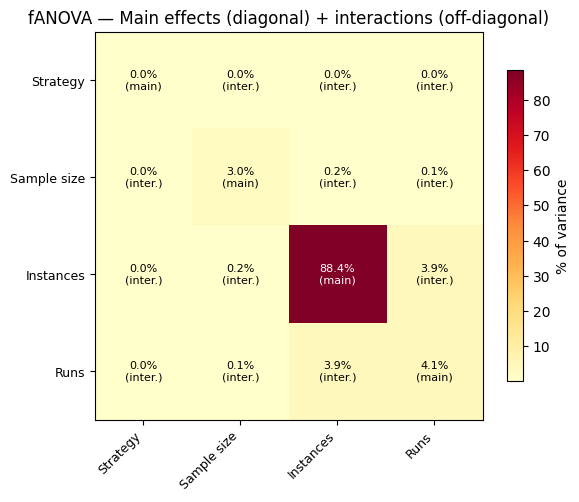

In [38]:
result = run_all(fold_agg_df, metric="acc_allruns_mean", omit_strategies="cma_random")


In [39]:
# run_all(fold_agg_df, metric="acc_mean", omit_strategies="cma_random",
#                       include_budget=True)

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Computing fANOVA per budget tier ...
  Tier (1199.999, 14400.0]: 144 rows, fitting RF ...


/Users/leekaijen/Documents/MSCS/thesis/MSc-Thesis-Problem-Embedding-Transfer-Learning/venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


  Tier (14400.0, 36000.0]: 136 rows, fitting RF ...


/Users/leekaijen/Documents/MSCS/thesis/MSc-Thesis-Problem-Embedding-Transfer-Learning/venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


  Tier (36000.0, 77700.0]: 104 rows, fitting RF ...


/Users/leekaijen/Documents/MSCS/thesis/MSc-Thesis-Problem-Embedding-Transfer-Learning/venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


  Tier (77700.0, 480000.0]: 128 rows, fitting RF ...

Summary:
        budget_tier              factor factor_label  importance_pct   importance  n_rows       r2
(1199.999, 14400.0]   sampling_strategy     Strategy        0.043940 2.205757e-06     144 0.848640
(1199.999, 14400.0] sample_size_per_dim  Sample size        0.100346 5.037337e-06     144 0.848640
(1199.999, 14400.0]   n_instances_train    Instances       91.104469 4.573395e-03     144 0.848640
(1199.999, 14400.0]        n_runs_train         Runs        2.805275 1.408233e-04     144 0.848640
 (14400.0, 36000.0]   sampling_strategy     Strategy        0.005632 9.395590e-08     136 0.914718
 (14400.0, 36000.0] sample_size_per_dim  Sample size        0.068336 1.139973e-06     136 0.914718
 (14400.0, 36000.0]   n_instances_train    Instances       22.131416 3.691944e-04     136 0.914718
 (14400.0, 36000.0]        n_runs_train         Runs       68.201838 1.137737e-03     136 0.914718
 (36000.0, 77700.0]   sampling_strategy     St

/Users/leekaijen/Documents/MSCS/thesis/MSc-Thesis-Problem-Embedding-Transfer-Learning/venv/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


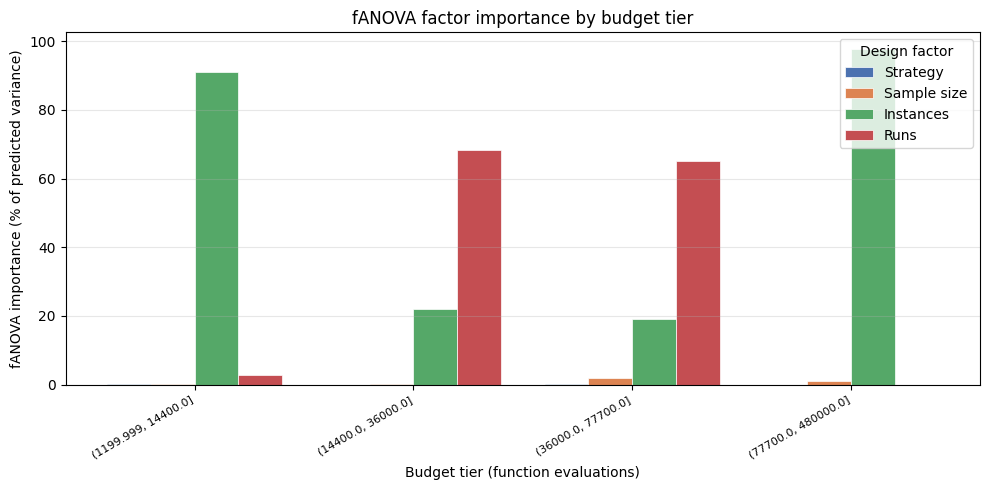

Plot 2: Relative fANOVA share by tier (stacked bars) ...


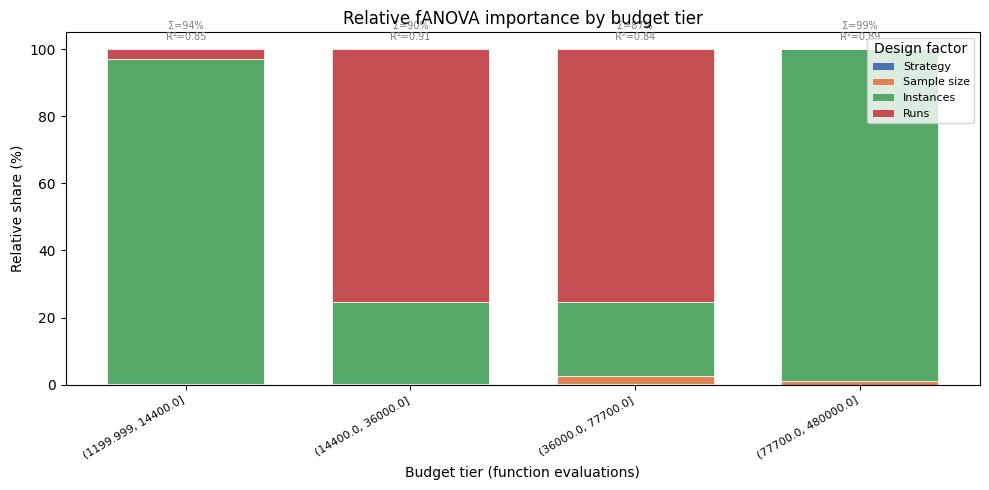

In [40]:
from rq2_fanova import *

tier_results, summary_df = run_by_tier(fold_agg_df, metric="acc_mean",
                                        omit_strategies="cma_random", n_tiers=4)

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Saturation curves for Strategy ...


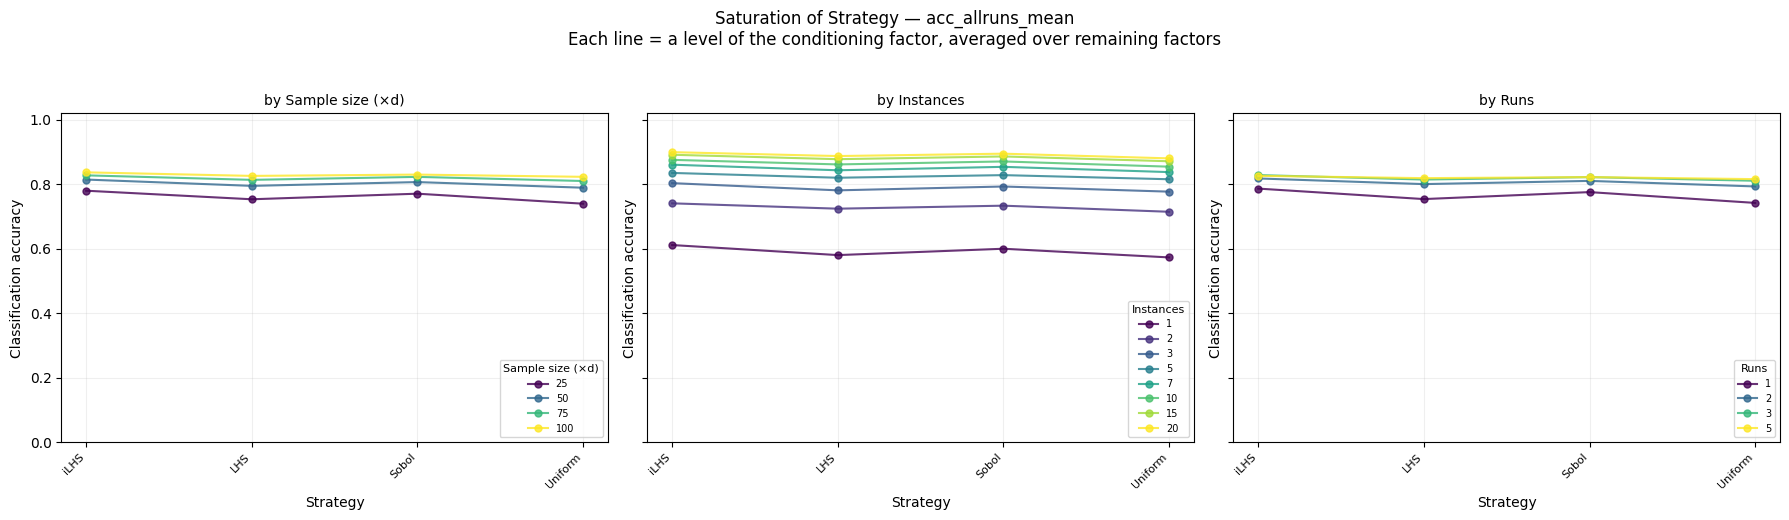

Saturation curves for Sample size (×d) ...


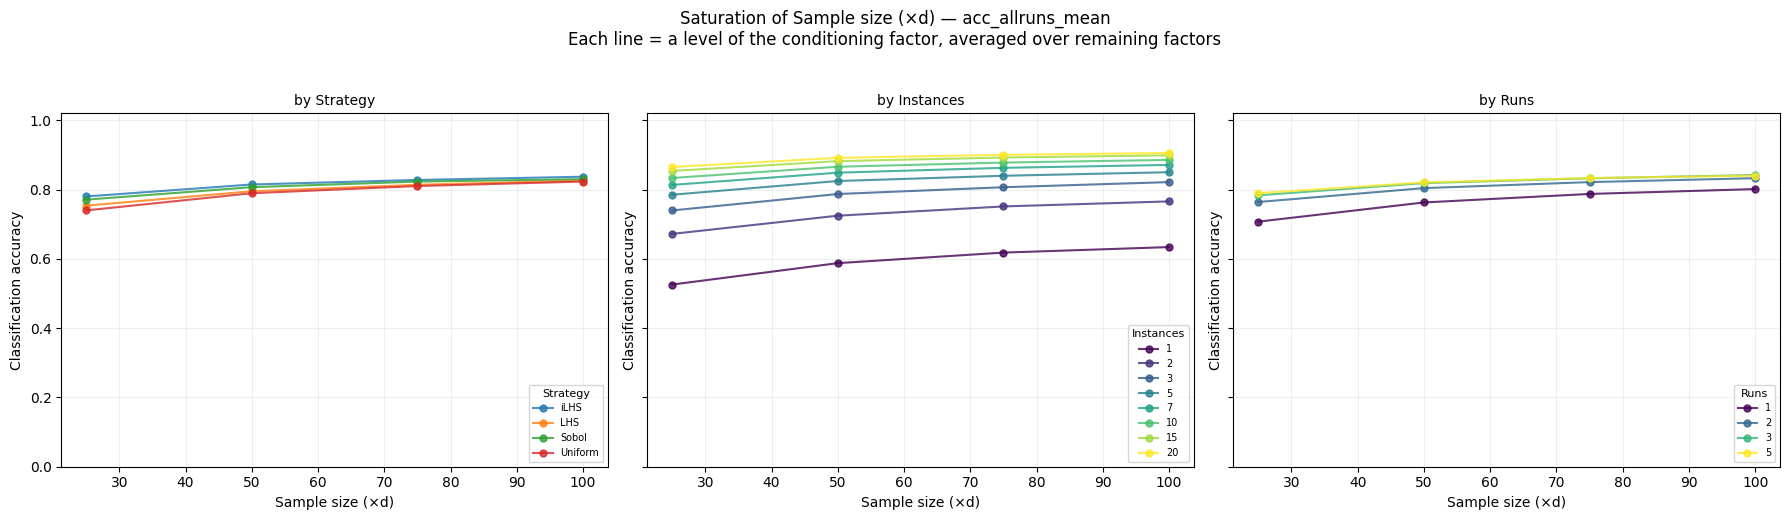

Saturation curves for Instances ...


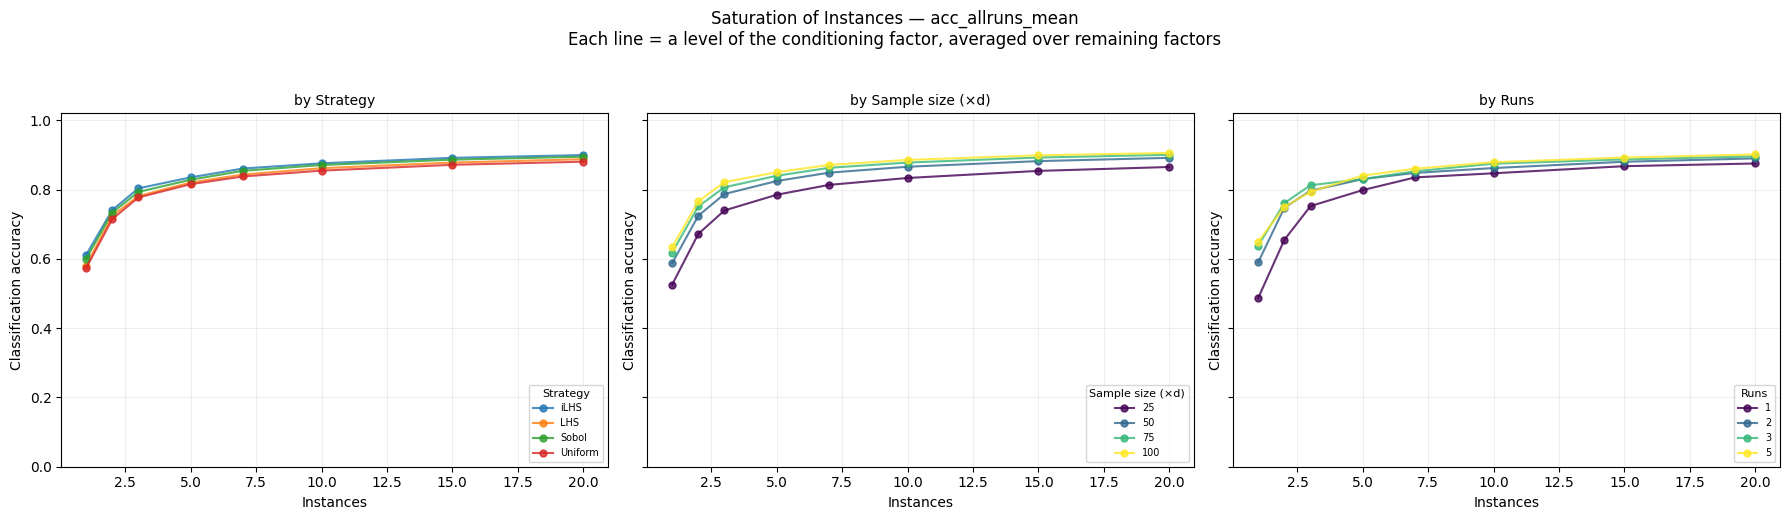

Saturation curves for Runs ...


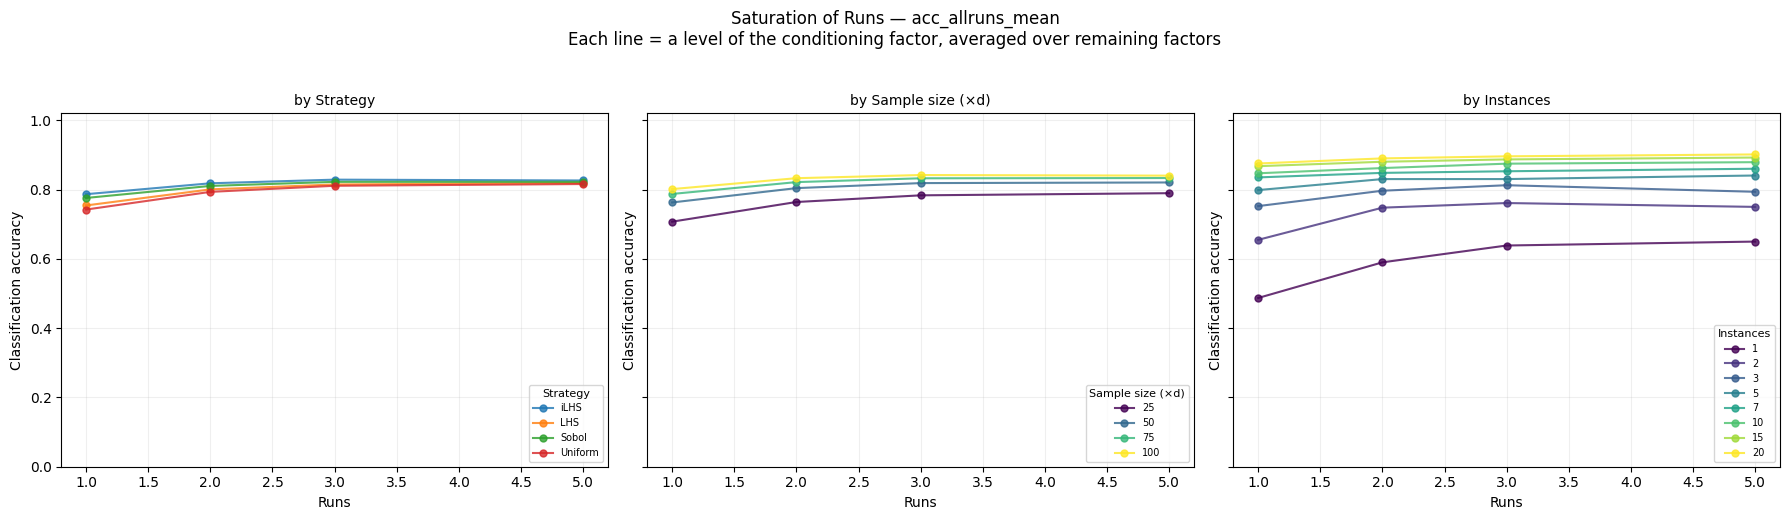

Marginal gains per step ...
          factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
Sample size (×d)          25        50   0.040450    0.068005          59.481026
Sample size (×d)          50        75   0.017142    0.068005          25.207344
Sample size (×d)          75       100   0.010413    0.068005          15.311630
       Instances           1         2   0.137104    0.299313          45.806114
       Instances           2         3   0.060340    0.299313          20.159415
       Instances           3         5   0.036139    0.299313          12.074021
       Instances           5         7   0.024135    0.299313           8.063316
       Instances           7        10   0.016679    0.299313           5.572586
       Instances          10        15   0.016096    0.299313           5.377695
       Instances          15        20   0.008820    0.299313           2.946853
            Runs           1         2   0.040924    0.056166          72.863494


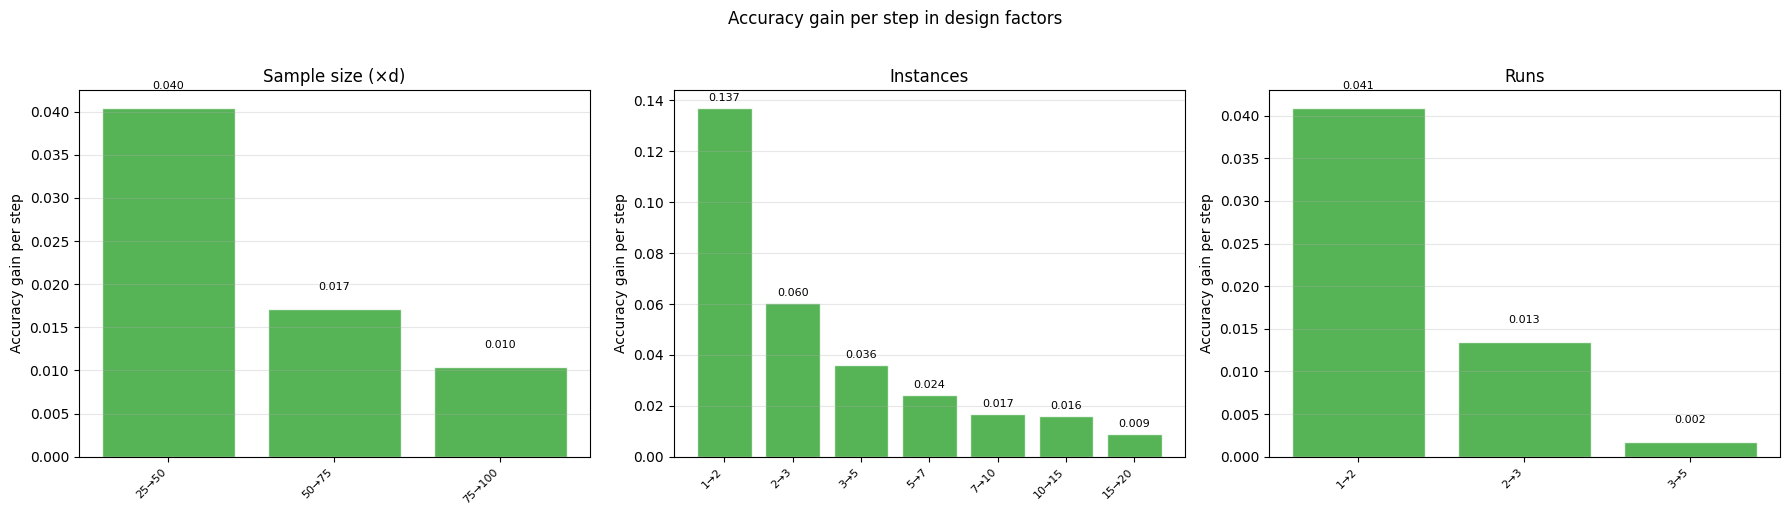

In [41]:
from rq2_saturation_curves import *

# All four factors + marginal gains table
gains_df = run_all(fold_agg_df, metric="acc_allruns_mean", omit_strategies="cma_random")

# Single factor deep-dive
# plot_saturation("n_instances_train", fold_agg_df, omit_strategies="cma_random")
# plot_saturation("n_runs_train", fold_agg_df, omit_strategies="cma_random")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Overall saturation by tier: Strategy ...


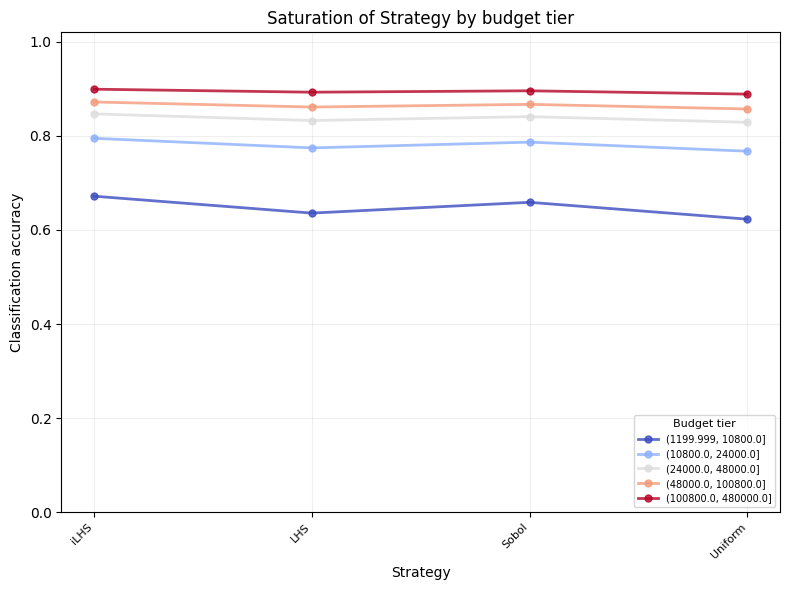

Overall saturation by tier: Sample size (×d) ...


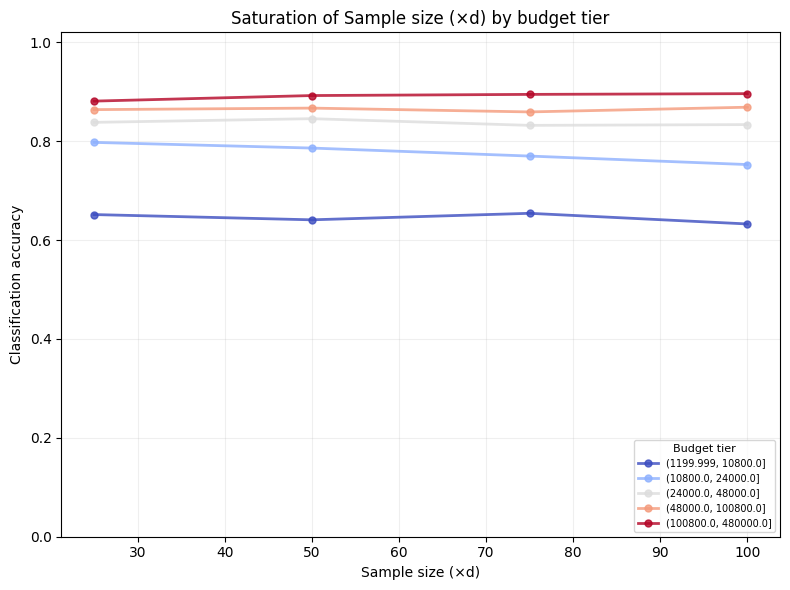

Overall saturation by tier: Instances ...


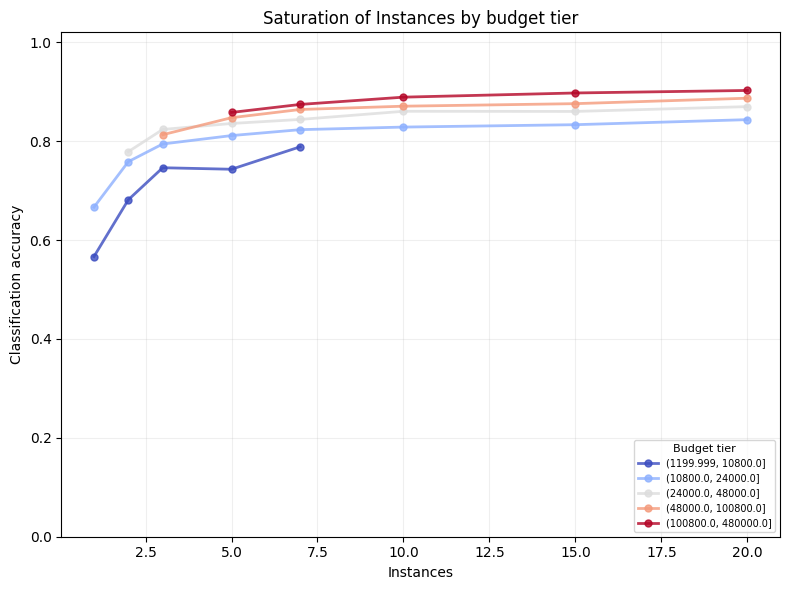

Overall saturation by tier: Runs ...


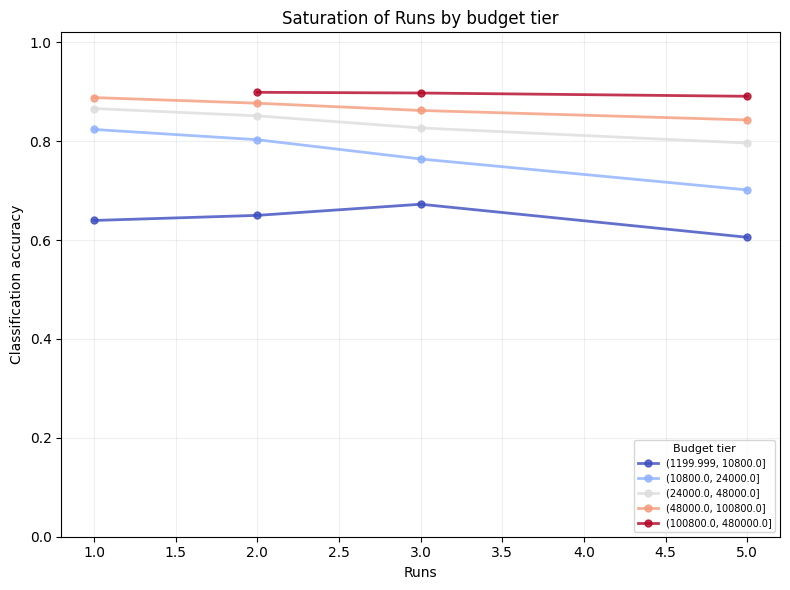

Per-tier saturation: Strategy ...


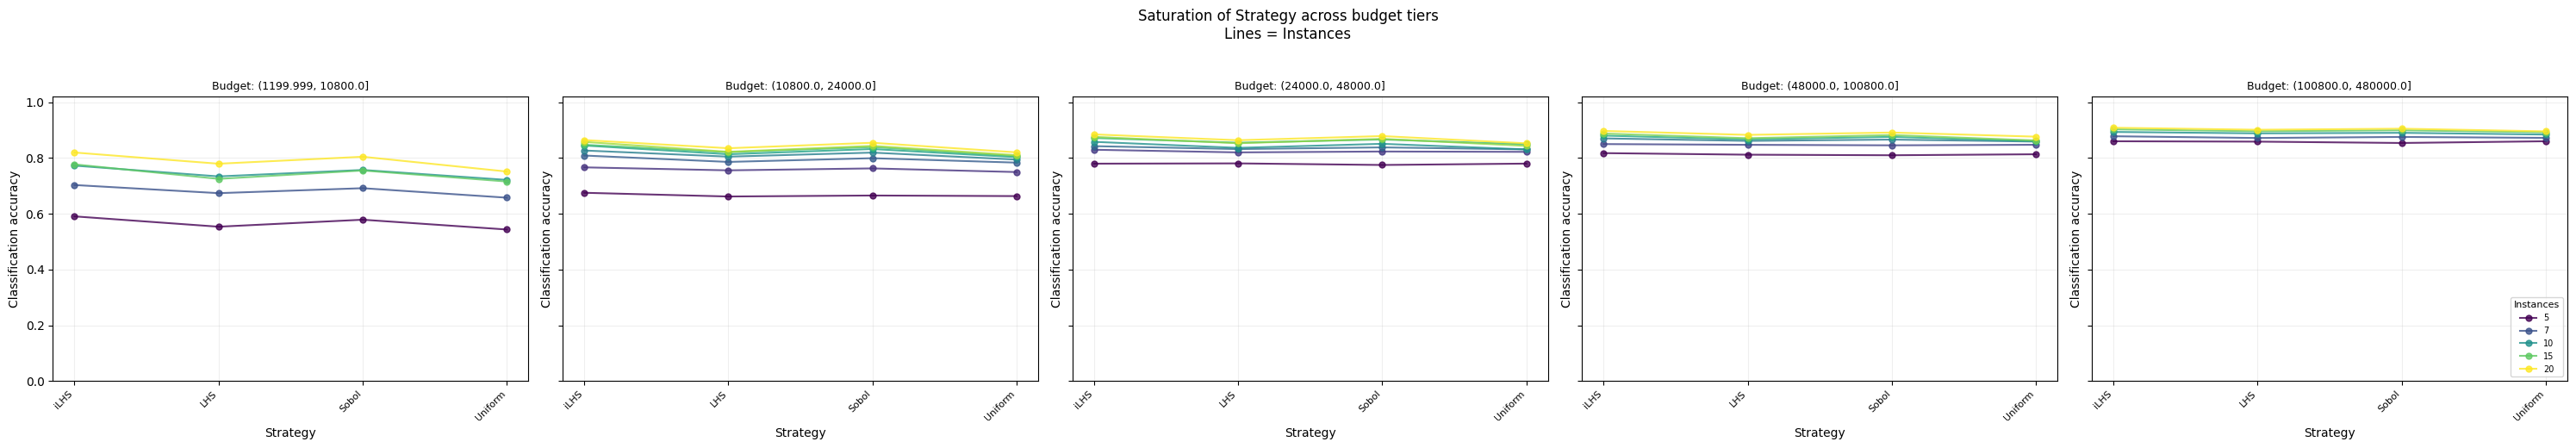

Per-tier saturation: Sample size (×d) ...


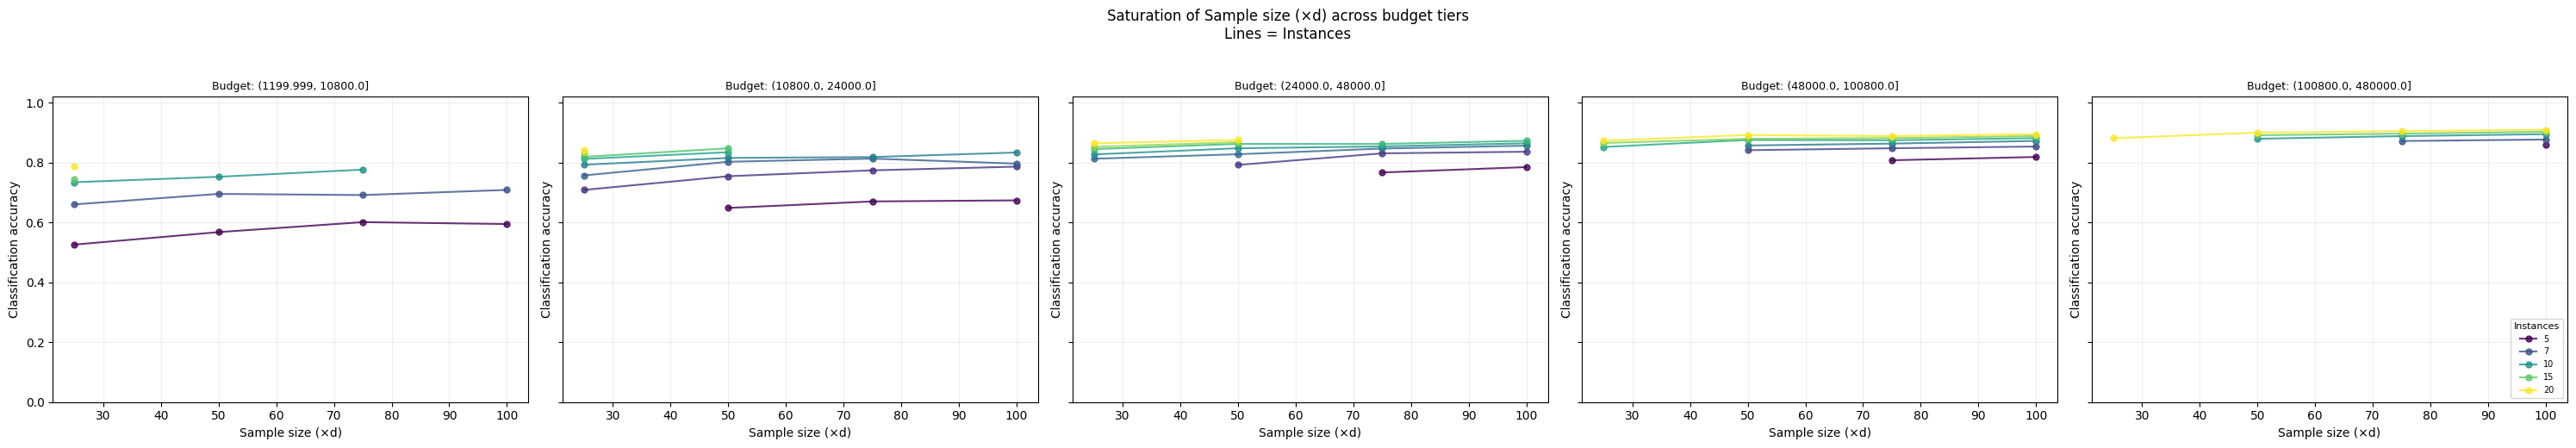

Per-tier saturation: Instances ...


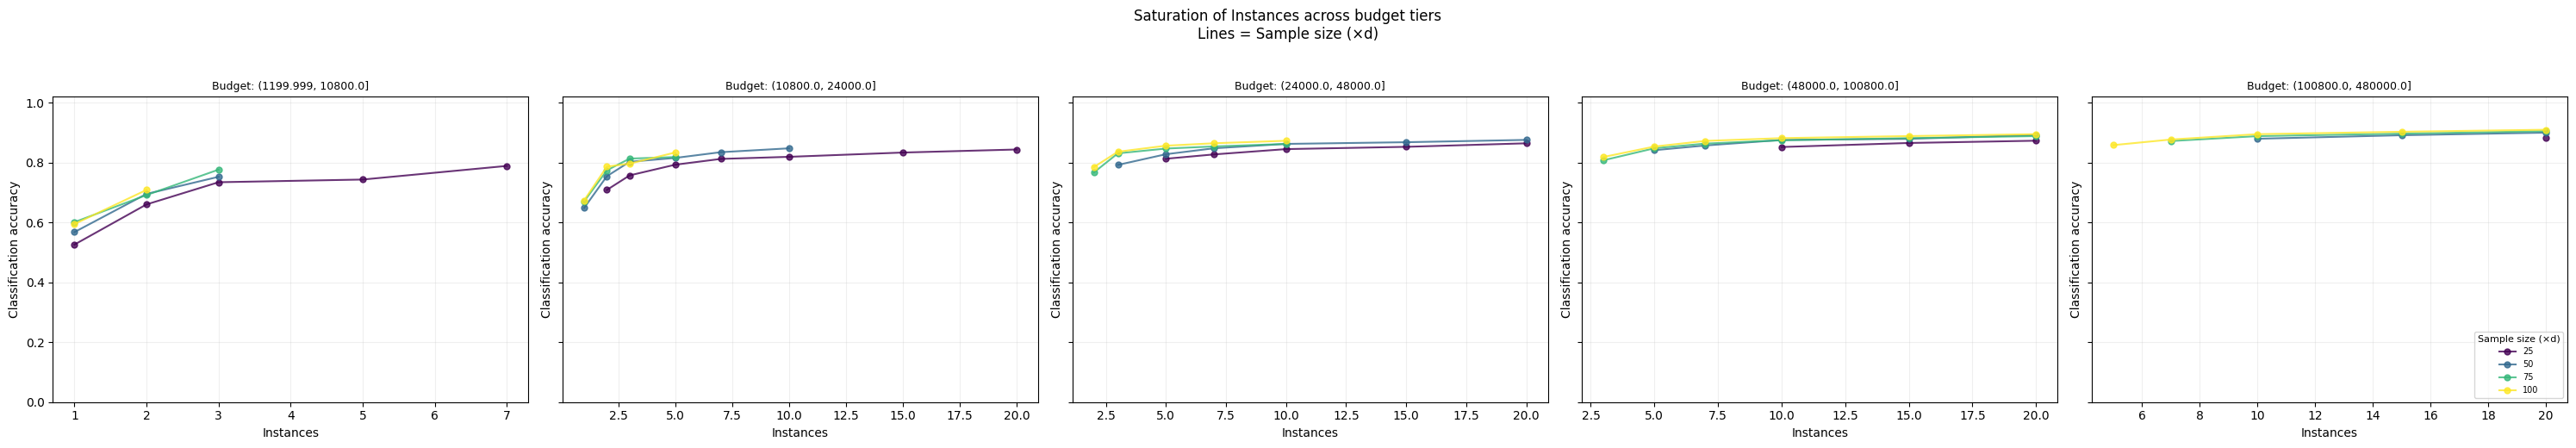

Per-tier saturation: Runs ...


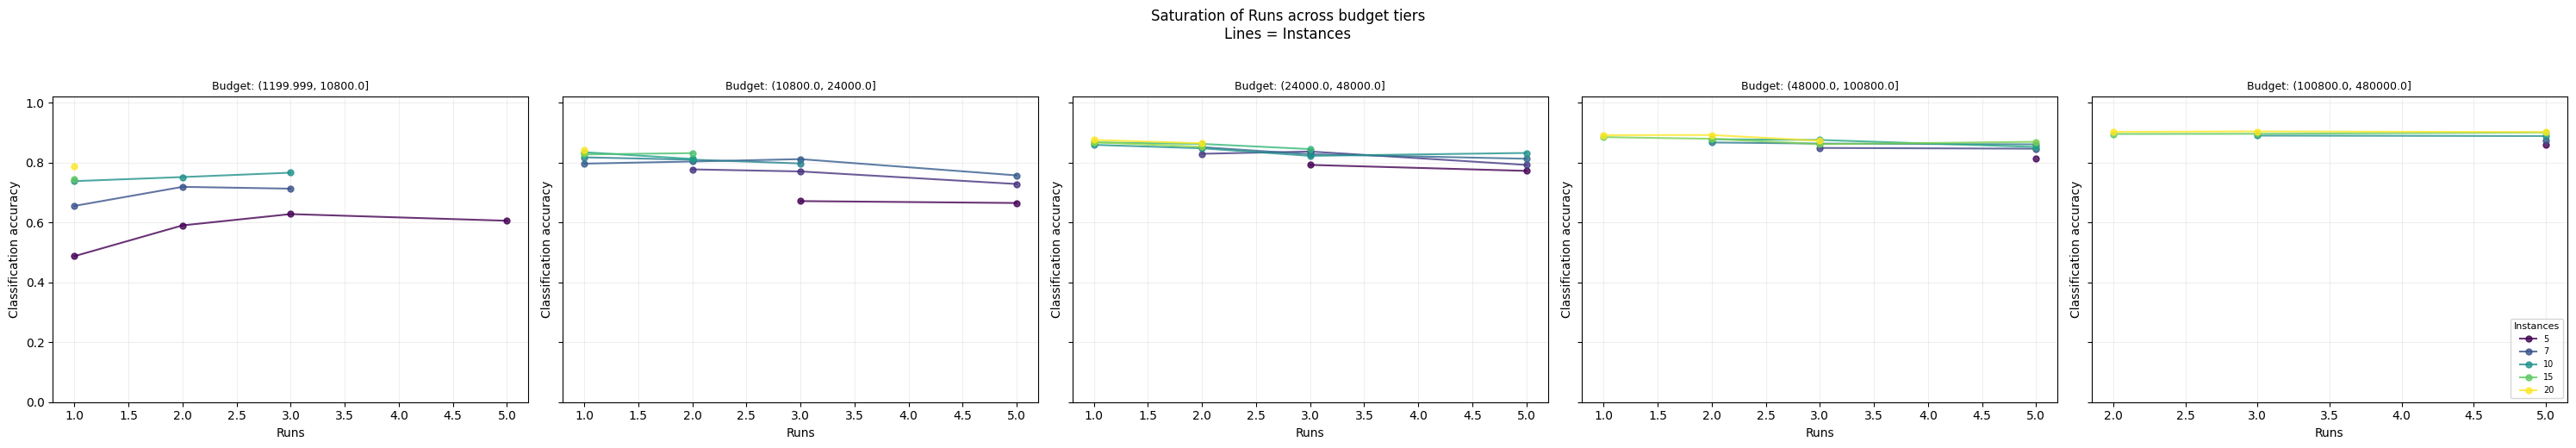

Marginal gains by tier ...
         budget_tier           factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
 (1199.999, 10800.0] Sample size (×d)          25        50  -0.010625   -0.018999          55.923350
 (1199.999, 10800.0] Sample size (×d)          50        75   0.013164   -0.018999         -69.288589
 (1199.999, 10800.0] Sample size (×d)          75       100  -0.021539   -0.018999         113.365239
 (1199.999, 10800.0]        Instances           1         2   0.114968    0.222124          51.758297
 (1199.999, 10800.0]        Instances           2         3   0.064719    0.222124          29.136479
 (1199.999, 10800.0]        Instances           3         5  -0.003049    0.222124          -1.372559
 (1199.999, 10800.0]        Instances           5         7   0.045486    0.222124          20.477782
 (1199.999, 10800.0]             Runs           1         2   0.010306   -0.034020         -30.294345
 (1199.999, 10800.0]             Runs           2      

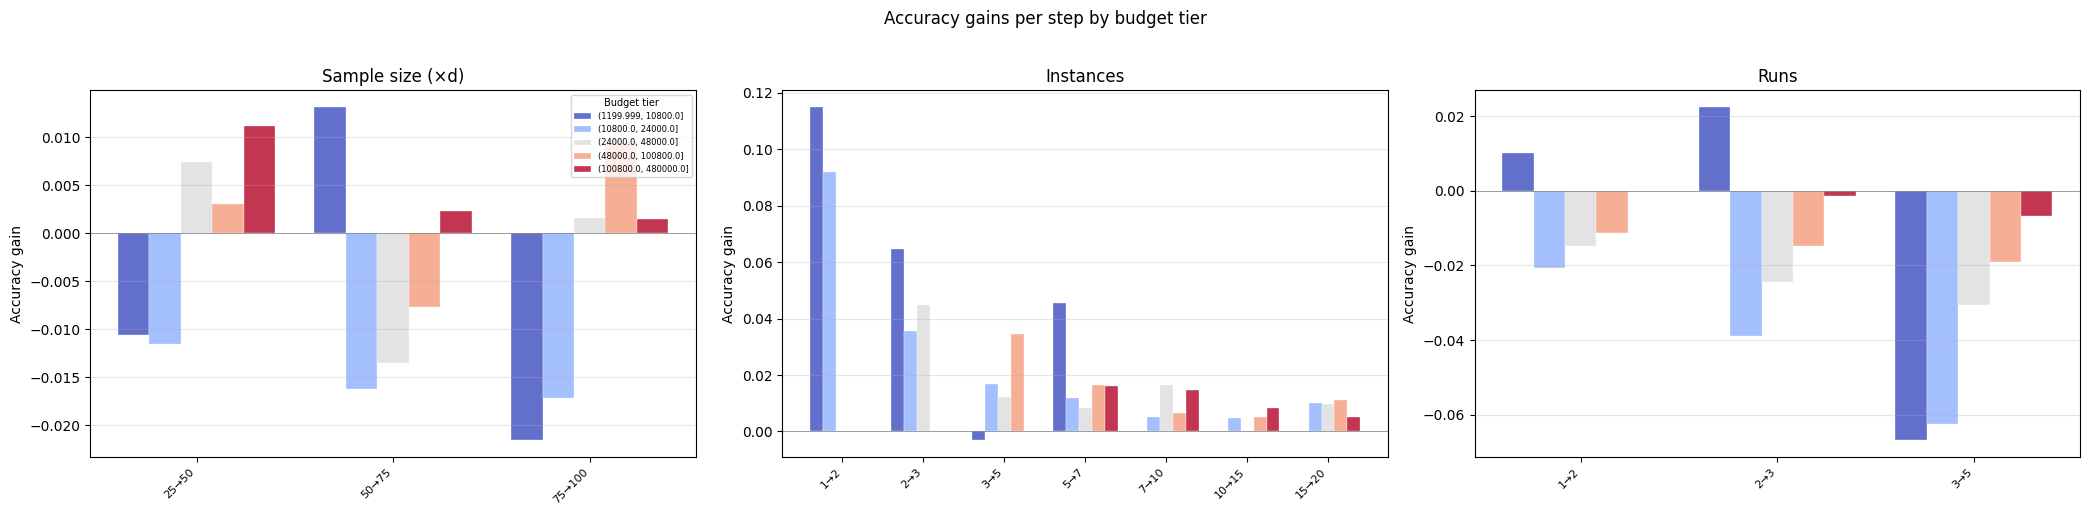

In [42]:
gains_by_tier = run_by_tier(fold_agg_df, metric="acc_allruns_mean",
                             omit_strategies="cma_random", n_tiers=5)

## Dimension 5

In [43]:
table_pkl_dim5 = Path("~/t7ssd/featELA/dim5featEla/classification_subsample/subsample_results_table.pkl")
df_dim5 = pd.read_pickle(table_pkl_dim5)
df_dim5 = df_dim5.drop(df_dim5[df_dim5.sample_size_per_dim == 10].index)
df_dim5


,dimension,sampling_strategy,sample_size_per_dim,n_instances_train,n_runs_train,n_feval_train,fold,n_features,n_omitted_features,omitted_features,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_median_mean,cv_training_folds_median_median,accuracy_median,accuracy_allruns,consistency
0,5,cma_random,25,1,1,3000,0,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.320312,0.282604,0.282604
1,5,cma_random,25,1,1,3000,1,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.379688,0.285017,0.285017
2,5,cma_random,25,1,1,3000,2,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.480729,0.298056,0.298056
3,5,cma_random,25,1,1,3000,3,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.317188,0.270313,0.270313
4,5,cma_random,25,1,1,3000,4,51,1,ela_meta.quad_simple.cond,0.358806,0.332018,0.701261,0.342616,NaN,NaN,0.398958,0.291476,0.291476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,5,uniform,100,20,5,1200000,0,51,1,ela_meta.quad_simple.cond,0.185245,0.081503,0.539473,0.113519,NaN,NaN,0.986458,0.973142,0.973142
1196,5,uniform,100,20,5,1200000,1,51,1,ela_meta.quad_simple.cond,0.185245,0.081503,0.539473,0.113519,NaN,NaN,0.976042,0.965920,0.965920
1197,5,uniform,100,20,5,1200000,2,51,1,ela_meta.quad_simple.cond,0.185245,0.081503,0.539473,0.113519,NaN,NaN,0.983854,0.968993,0.968993
1198,5,uniform,100,20,5,1200000,3,51,1,ela_meta.quad_simple.cond,0.185245,0.081503,0.539473,0.113519,NaN,NaN,0.979688,0.969514,0.969514


In [44]:
df_unique = df_dim5.drop_duplicates(subset=["sampling_strategy", "sample_size_per_dim"])
pivot = df_unique.pivot(index="sampling_strategy", columns="sample_size_per_dim",
                        values="cv_instance_median_mean")
pivot

sample_size_per_dim,25,50,75,100
sampling_strategy,,,,
cma_random,0.358806,0.384086,0.398968,0.428547
ilhs,0.231247,0.177530,0.151934,0.130748
lhs,0.264961,0.213222,0.192445,0.179243
sobol,0.227215,0.177535,0.156443,0.125253
uniform,0.263006,0.218350,0.198319,0.185245


In [45]:
df_dim5["n_feval_train"].value_counts()


n_feval_train
60000      100
180000     100
45000       75
30000       75
90000       75
300000      75
9000        50
15000       50
150000      50
120000      50
360000      50
600000      50
3000        25
75000       25
6000        25
18000       25
27000       25
135000      25
225000      25
270000      25
450000      25
540000      25
900000      25
12000       25
36000       25
240000      25
720000      25
1200000     25
Name: count, dtype: int64

KeyError: 'cv'

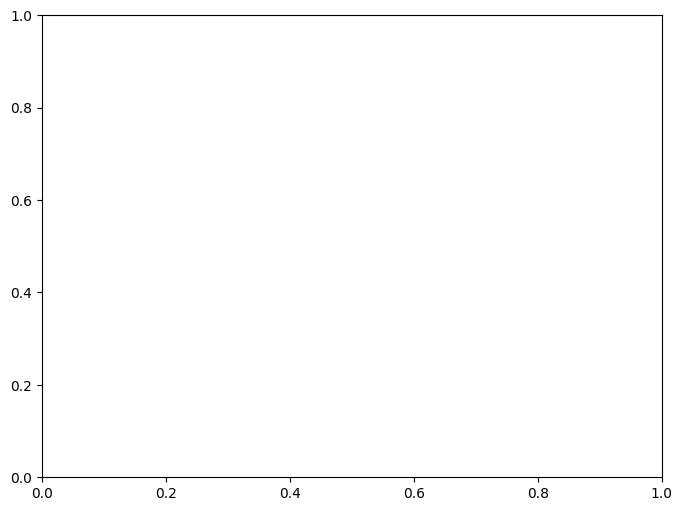

In [46]:
plot_cv_vs_accuracy(df_dim5)

In [ ]:
# Best config per strategy (highest accuracy)
df_dim5.loc[df_dim5.groupby("sampling_strategy")["accuracy_median_mean"].idxmax()]